# Road Accident Severity Prediction using Machine Learning

## Phase 4 — Exploratory Data Analysis (EDA)

---

**Project:** Road Accident Severity Prediction using Machine Learning
**Institution:** On-Campus Research Internship, IIIT Vadodara
**Notebook:** `03_Exploratory_Data_Analysis.ipynb`
**Phase:** 4 of N — Exploratory Data Analysis
**Input Dataset:** `Dataset/processed/cleaned_accident_data.csv`
**Target Variable:** `Accident_Severity`

---

### Objective of this Notebook

This notebook explores the cleaned dataset produced in Phase 3
(`02_Data_Preprocessing.ipynb`) to understand its structure, discover hidden patterns,
identify relationships between features and accident severity, detect class imbalance,
and generate research-quality insights that will guide future feature engineering and
model building.

Specifically, this notebook:

1. Profiles the cleaned dataset's shape, types, and memory footprint.
2. Analyzes the distribution and imbalance of the target variable, `Accident_Severity`.
3. Explores every numerical feature's distribution and outliers.
4. Explores key categorical features and ranks their categories by frequency.
5. Analyzes temporal patterns (year, month, day of week, hour of day).
6. Examines how `Accident_Severity` varies across key situational factors.
7. Generates a correlation heatmap across numerical features.
8. Consolidates a dedicated outlier analysis (without removing any outliers).
9. Summarizes at least 10 research-quality insights from the analysis.

> **Scope restriction:** This notebook performs **exploratory data analysis only**. It
> does **not** train machine learning models, perform feature engineering, encode
> variables, normalize or scale data, or build any modeling pipeline. All plots are
> automatically saved to `reports/figures/`.


---
## Setup — Import Libraries & Configure Environment

**Purpose:** Import the libraries required for EDA and configure plotting style,
pandas display options, and the output directory for saved figures.


In [1]:
# ---- Core Libraries ----
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- Environment Configuration ----
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ---- Output Directory for Figures ----
FIGURES_DIR = Path("..") / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = "Accident_Severity"


def save_figure(fig, filename: str) -> Path:
    '''
    Save a matplotlib figure to the reports/figures/ directory with a
    meaningful filename, creating the directory if necessary.

    Args:
        fig: The matplotlib Figure object to save.
        filename (str): Filename (including extension) to save the figure as.

    Returns:
        Path: The full path the figure was saved to.
    '''
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, bbox_inches="tight", dpi=150)
    print(f"Figure saved to: {output_path.resolve()}")
    return output_path


def column_exists(df: pd.DataFrame, column: str) -> bool:
    '''
    Check whether a column exists in the dataframe, printing a clear
    skip-message if it does not (so the notebook degrades gracefully
    rather than raising a KeyError).

    Args:
        df (pd.DataFrame): The dataframe to check.
        column (str): Column name to check for.

    Returns:
        bool: True if the column exists, False otherwise.
    '''
    exists = column in df.columns
    if not exists:
        print(f"[SKIPPED] Column '{column}' was not found in the cleaned dataset.")
    return exists


print("Libraries imported and environment configured successfully.")
print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")


Libraries imported and environment configured successfully.
Figures will be saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures


**Observations**

- Only `pandas`, `numpy`, `matplotlib`, and `seaborn` are used, per the coding style
  requirements for this phase.
- `save_figure()` and `column_exists()` are small, reusable utilities used throughout
  the notebook to avoid duplicated code and to let every section degrade gracefully if
  a particular column is not present in the final cleaned dataset (e.g., if it was
  dropped in Phase 3 due to excessive missingness).


---
## Load the Cleaned Dataset

**Purpose:** Load `Dataset/processed/cleaned_accident_data.csv` (produced in Phase 3)
using robust exception handling, consistent with prior notebooks.


In [2]:
PROCESSED_DATA_PATH = Path("..") / "Dataset" / "processed" / "cleaned_accident_data.csv"

try:
    if not PROCESSED_DATA_PATH.exists():
        raise FileNotFoundError(
            f"Cleaned dataset not found at: {PROCESSED_DATA_PATH.resolve()}. "
            f"Please run 02_Data_Preprocessing.ipynb first."
        )
    df = pd.read_csv(PROCESSED_DATA_PATH, low_memory=False)
    print(f"Cleaned dataset loaded successfully from: {PROCESSED_DATA_PATH.resolve()}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
except (FileNotFoundError, pd.errors.EmptyDataError, pd.errors.ParserError) as error:
    print(f"[ERROR] {error}")
    raise


Cleaned dataset loaded successfully from: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\Dataset\processed\cleaned_accident_data.csv
Shape: 2,715,940 rows x 38 columns


In [3]:
# Parse known date/time columns back into proper types for temporal analysis,
# since round-tripping through CSV stores them as plain strings.
if column_exists(df, "Date"):
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

if column_exists(df, "Time"):
    df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce").dt.time

print("Date/Time columns re-parsed for analysis (read-only; the saved CSV is unchanged).")


Date/Time columns re-parsed for analysis (read-only; the saved CSV is unchanged).


**Observations**

- The cleaned dataset is loaded directly from the Phase 3 output with no further
  modification beyond re-parsing `Date`/`Time` columns, which are always read back from
  CSV as plain strings — this re-parsing is purely for in-memory analysis convenience
  and does not alter the saved file on disk.


---
## 1. Dataset Overview

**Purpose:** Establish a high-level structural profile of the cleaned dataset — shape,
data types, memory usage, and any remaining missing values after preprocessing.


In [4]:
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print("Dataset Overview")
print(f"  Number of Rows     : {df.shape[0]:,}")
print(f"  Number of Columns  : {df.shape[1]}")
print(f"  Memory Usage (MB)  : {memory_mb:.2f}")


Dataset Overview
  Number of Rows     : 2,715,940
  Number of Columns  : 38
  Memory Usage (MB)  : 4183.23


In [5]:
dtype_table = pd.DataFrame(
    {"Column Name": df.columns, "Data Type": df.dtypes.astype(str).values}
)
dtype_table


,Column Name,Data Type
0,1st_Road_Class,object
1,Accident_Severity,object
2,Date,datetime64[ns]
3,Day_of_Week,object
4,Did_Police_Officer_Attend_Scene_of_Accident,float64
5,Junction_Control,object
6,Junction_Detail,object
7,Latitude,float64
8,Light_Conditions,object
9,Local_Authority_(District),object


In [6]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if missing_summary.empty:
    print("No missing values remain in the cleaned dataset.")
else:
    print(f"{len(missing_summary)} column(s) still contain missing values:")
    display(missing_summary.to_frame("Missing Count"))


1 column(s) still contain missing values:


,Missing Count
Date,1632422


**Interpretation**

- This overview confirms the scale of data available for exploratory analysis, and
  re-verifies that Phase 3's missing-value handling left the dataset in the expected
  state (ideally zero remaining missing values, since columns were either imputed or
  dropped in preprocessing).
- Data type awareness here directly drives which plots are appropriate later:
  numerical columns are profiled with histograms/box plots, while `category`/`object`
  columns are profiled with count plots.


---
## 2. Target Variable Analysis

**Purpose:** Visualize and quantify the distribution of `Accident_Severity` to assess
class imbalance, which has major implications for later model training and evaluation
strategy.


In [7]:
severity_counts = df[TARGET_COLUMN].value_counts()
severity_percentages = df[TARGET_COLUMN].value_counts(normalize=True) * 100

severity_summary = pd.DataFrame(
    {
        "Severity": severity_counts.index,
        "Count": severity_counts.values,
        "Percentage (%)": severity_percentages.values.round(2),
    }
)
severity_summary


,Severity,Count,Percentage (%)
0,Slight,2315841,85.27
1,Serious,364619,13.43
2,Fatal,35480,1.31


Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\target_accident_severity_distribution.png


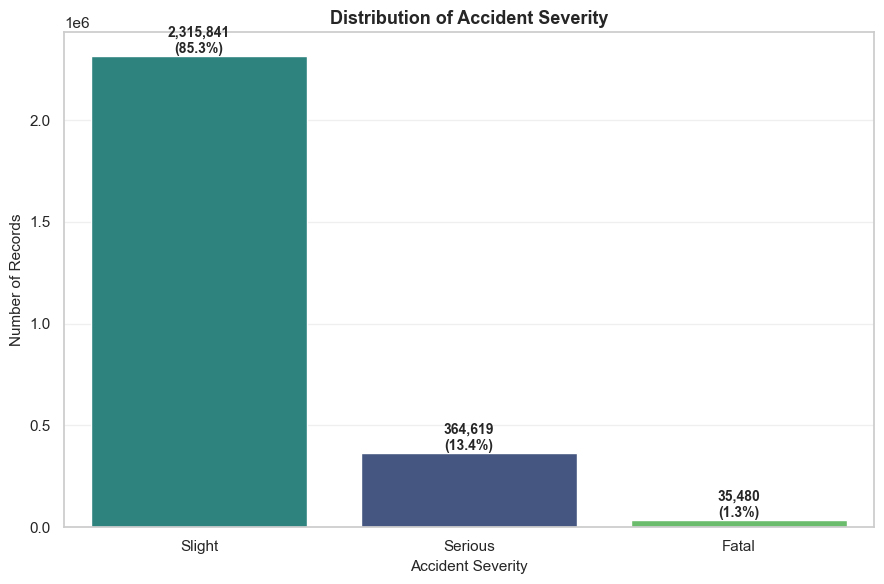

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))

order = severity_counts.index
bars = sns.countplot(data=df, x=TARGET_COLUMN, order=order, hue=TARGET_COLUMN,
                      palette="viridis", legend=False, ax=ax)

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = (count / total) * 100
    ax.annotate(
        f"{count:,}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

ax.set_title("Distribution of Accident Severity", fontweight="bold")
ax.set_xlabel("Accident Severity")
ax.set_ylabel("Number of Records")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_figure(fig, "target_accident_severity_distribution.png")
plt.show()


**Interpretation**

- **What it shows:** The count and percentage of records falling into each
  `Accident_Severity` category (typically `Slight`, `Serious`, `Fatal` in UK STATS19
  data).
- **Why it matters:** Road accident datasets are almost universally **imbalanced** —
  `Slight` accidents vastly outnumber `Serious` and especially `Fatal` accidents, since
  fatal outcomes are (fortunately) rare events relative to total accidents.
- **Impact on prediction:** Severe class imbalance means a naive model could achieve
  high overall accuracy simply by always predicting the majority class (`Slight`) while
  completely failing to identify `Fatal` accidents — the class that matters most for
  road safety interventions. This motivates the use of **stratified sampling,
  class-weighted loss functions, resampling techniques (e.g., SMOTE), and metrics
  beyond accuracy** (e.g., macro F1-score, recall on the minority class) in the
  modeling phase.


---
## 3. Numerical Feature Analysis

**Purpose:** For every numerical feature in the cleaned dataset, generate a histogram
(distribution shape) and a box plot (spread and outliers), and compute automatic,
data-driven diagnostics (skewness and IQR-based outlier counts) to objectively
characterize each feature — without modifying, removing, or transforming any values.

A single reusable function handles every numerical column dynamically, so this section
automatically adapts to whichever numerical columns survive Phase 3 preprocessing,
without hardcoding column names.


Numerical columns detected: ['Did_Police_Officer_Attend_Scene_of_Accident', 'Latitude', 'Longitude', 'Number_of_Vehicles', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Speed_limit', 'Year_accident', 'Age_of_Vehicle', 'Engine_Capacity_.CC.', 'Vehicle_Location.Restricted_Lane', 'Year_vehicle']

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Did_Police_Officer_Attend_Scene_of_Accident_distribution.png


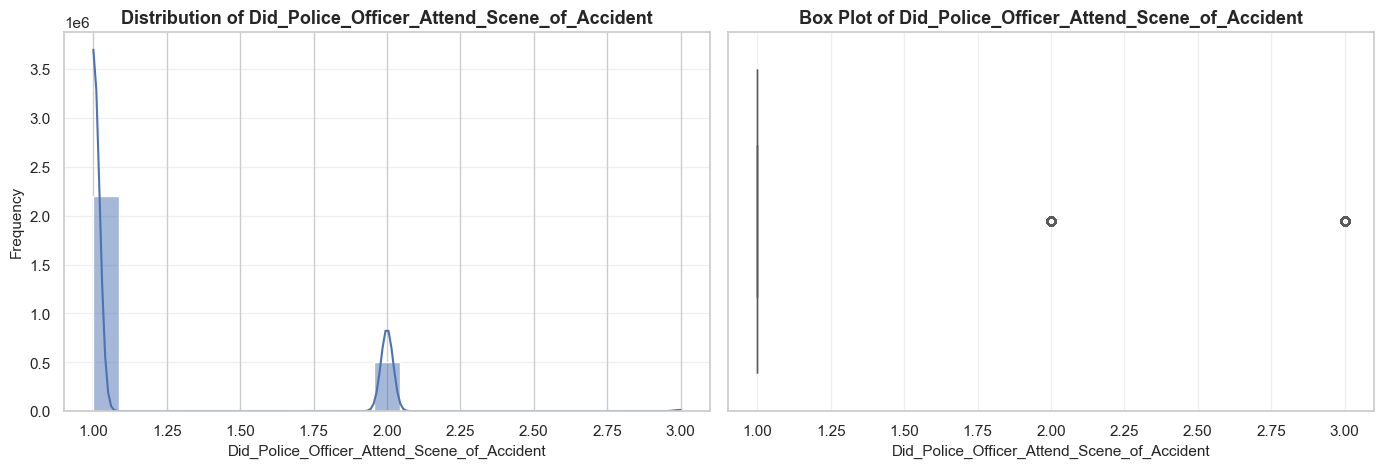

'Did_Police_Officer_Attend_Scene_of_Accident': skewness = 1.698 (highly skewed); 511,592 outlier(s) detected (18.84% of non-null values), using the 1.5 x IQR rule [1.0, 1.0].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Latitude_distribution.png


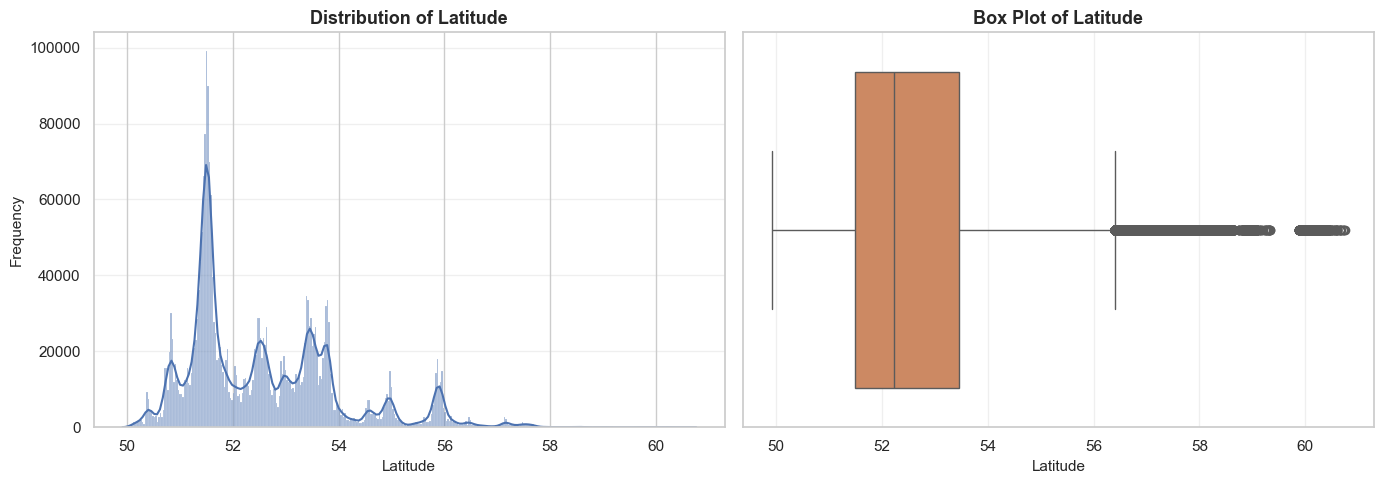

'Latitude': skewness = 1.026 (highly skewed); 35,921 outlier(s) detected (1.32% of non-null values), using the 1.5 x IQR rule [48.53, 56.4].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Longitude_distribution.png


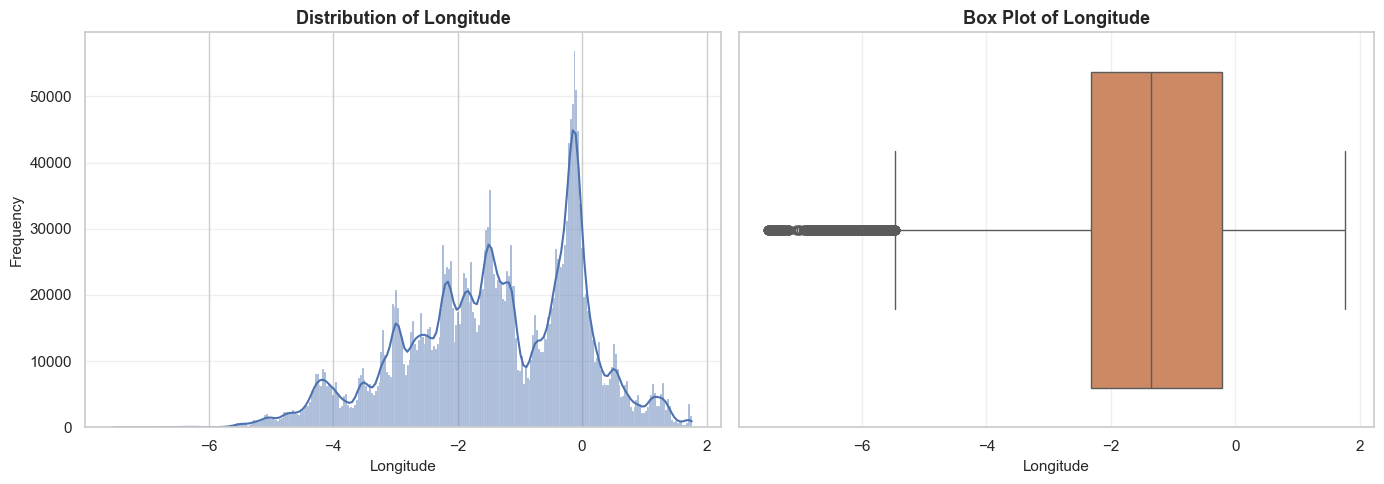

'Longitude': skewness = -0.394 (approximately symmetric); 3,554 outlier(s) detected (0.13% of non-null values), using the 1.5 x IQR rule [-5.47, 2.95].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Number_of_Vehicles_distribution.png


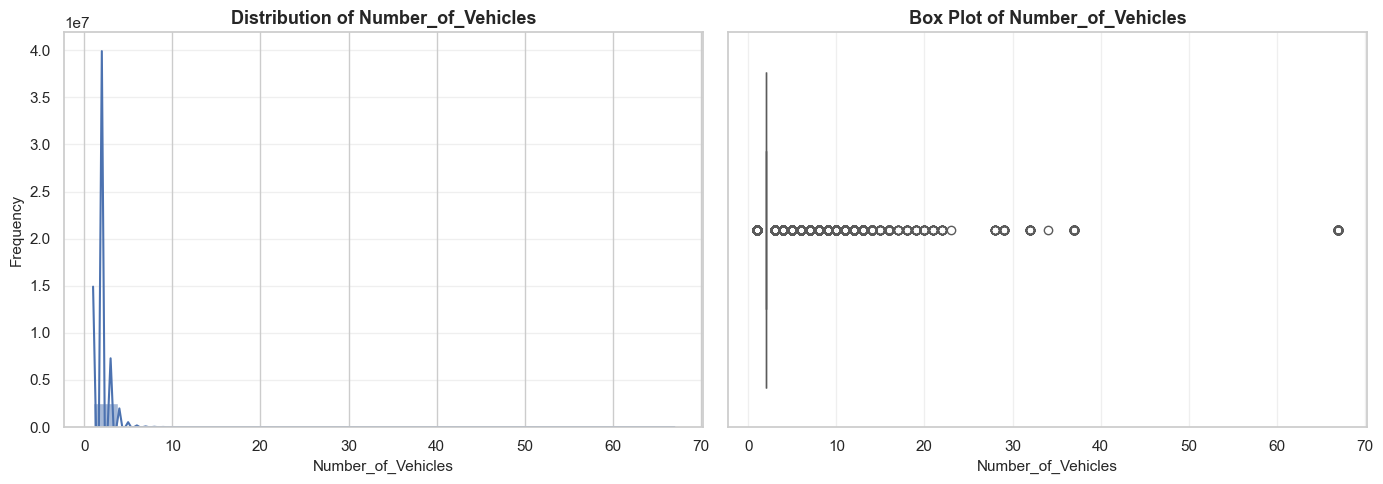

'Number_of_Vehicles': skewness = 10.367 (highly skewed); 1,053,722 outlier(s) detected (38.8% of non-null values), using the 1.5 x IQR rule [2.0, 2.0].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Pedestrian_Crossing-Human_Control_distribution.png


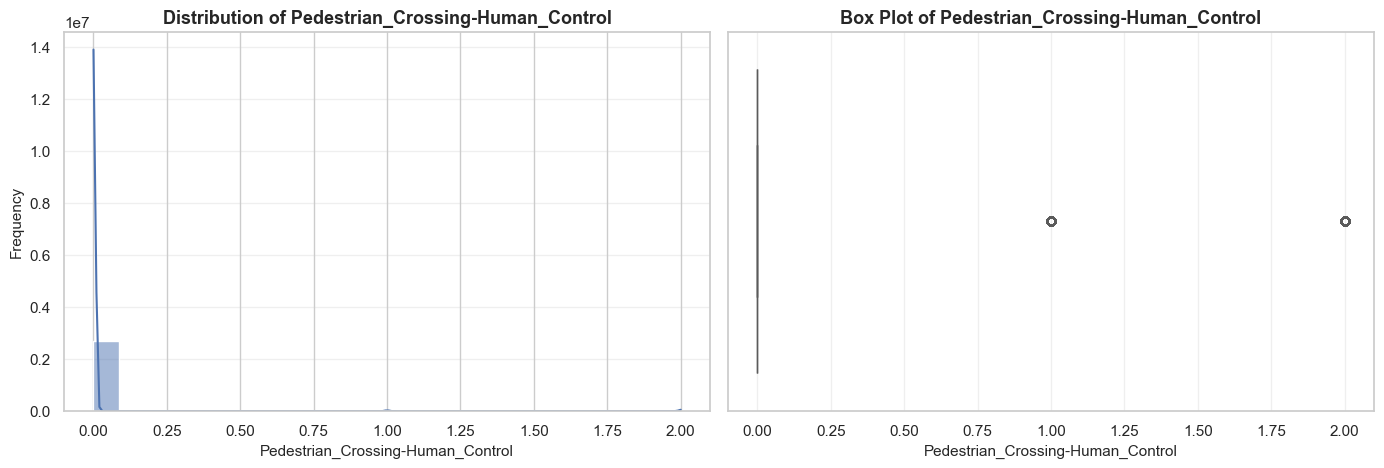

'Pedestrian_Crossing-Human_Control': skewness = 14.183 (highly skewed); 16,211 outlier(s) detected (0.6% of non-null values), using the 1.5 x IQR rule [0.0, 0.0].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Pedestrian_Crossing-Physical_Facilities_distribution.png


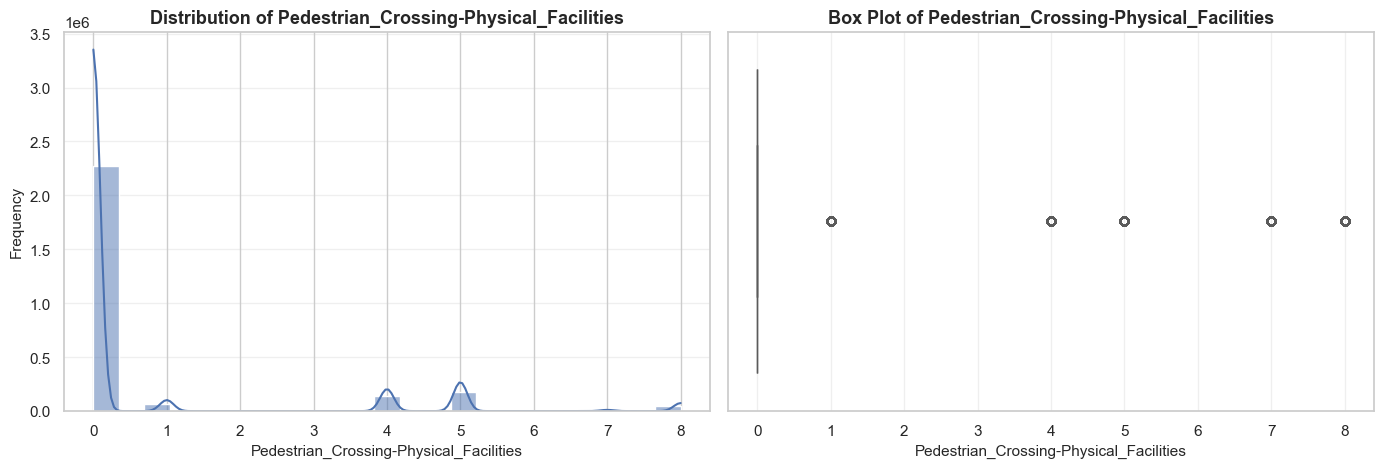

'Pedestrian_Crossing-Physical_Facilities': skewness = 2.411 (highly skewed); 447,411 outlier(s) detected (16.47% of non-null values), using the 1.5 x IQR rule [0.0, 0.0].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Speed_limit_distribution.png


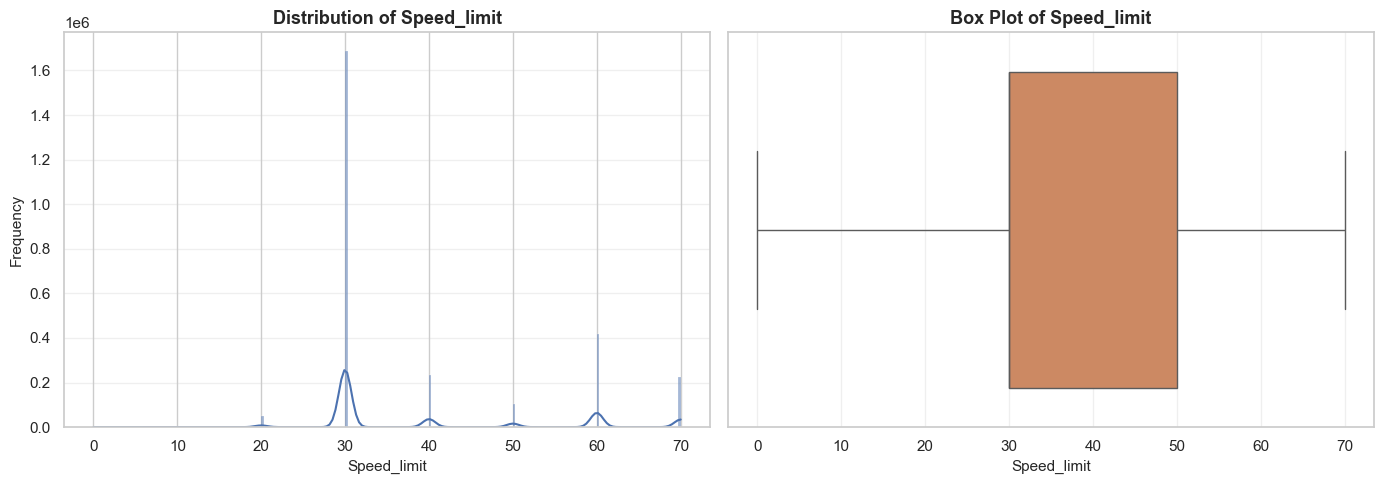

'Speed_limit': skewness = 1.04 (highly skewed); 0 outlier(s) detected (0.0% of non-null values), using the 1.5 x IQR rule [0.0, 80.0].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Year_accident_distribution.png


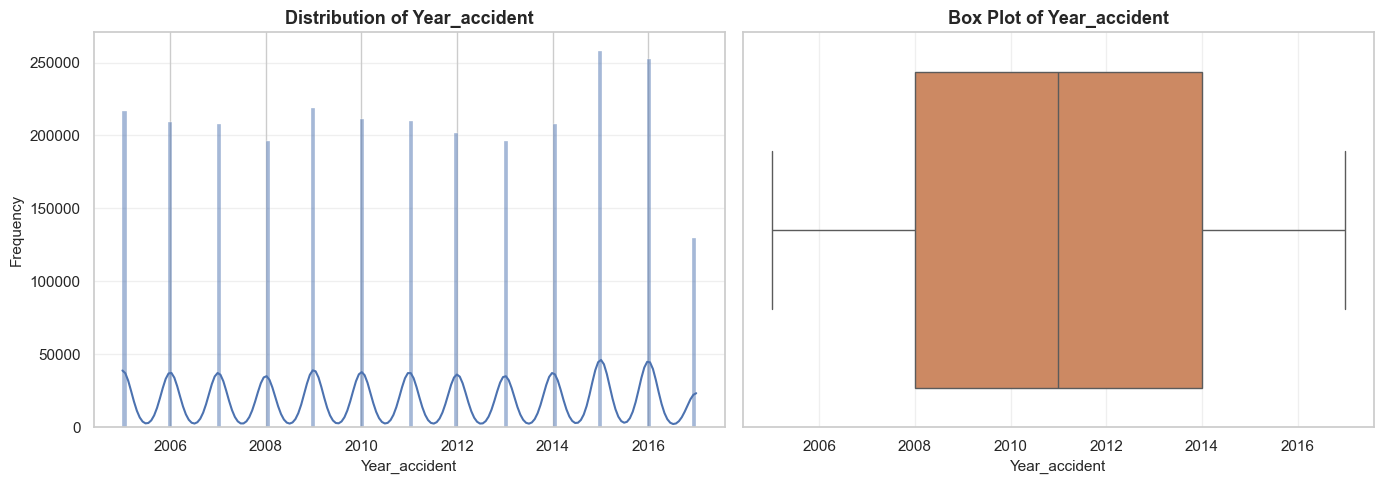

'Year_accident': skewness = -0.036 (approximately symmetric); 0 outlier(s) detected (0.0% of non-null values), using the 1.5 x IQR rule [1999.0, 2023.0].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Age_of_Vehicle_distribution.png


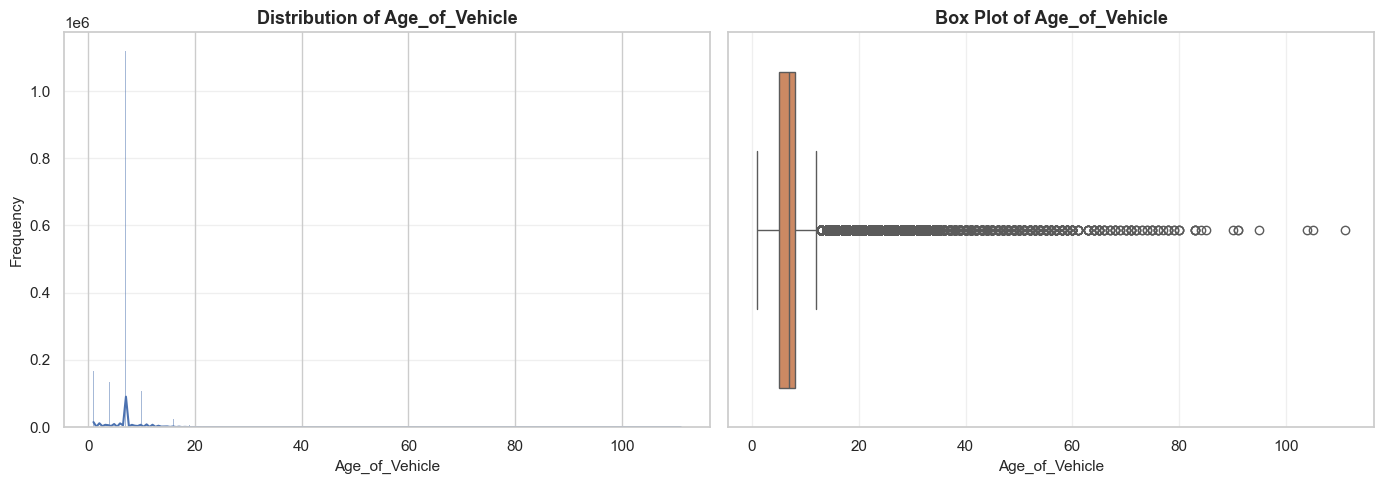

'Age_of_Vehicle': skewness = 1.58 (highly skewed); 222,267 outlier(s) detected (8.18% of non-null values), using the 1.5 x IQR rule [0.5, 12.5].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Engine_Capacity_.CC._distribution.png


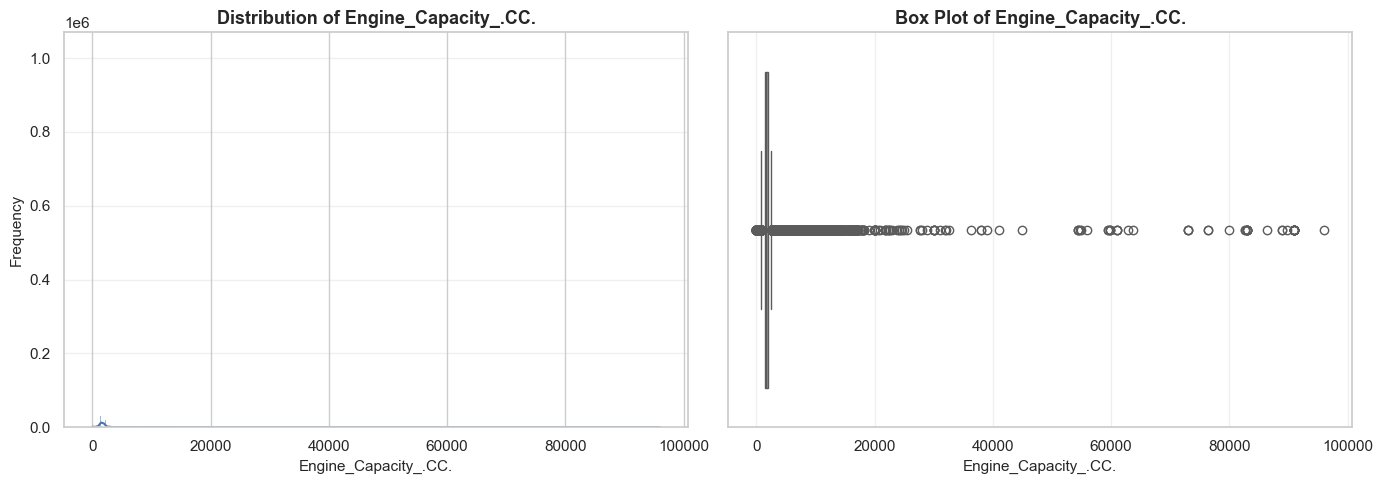

'Engine_Capacity_.CC.': skewness = 6.659 (highly skewed); 328,730 outlier(s) detected (12.1% of non-null values), using the 1.5 x IQR rule [808.5, 2548.5].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Vehicle_Location.Restricted_Lane_distribution.png


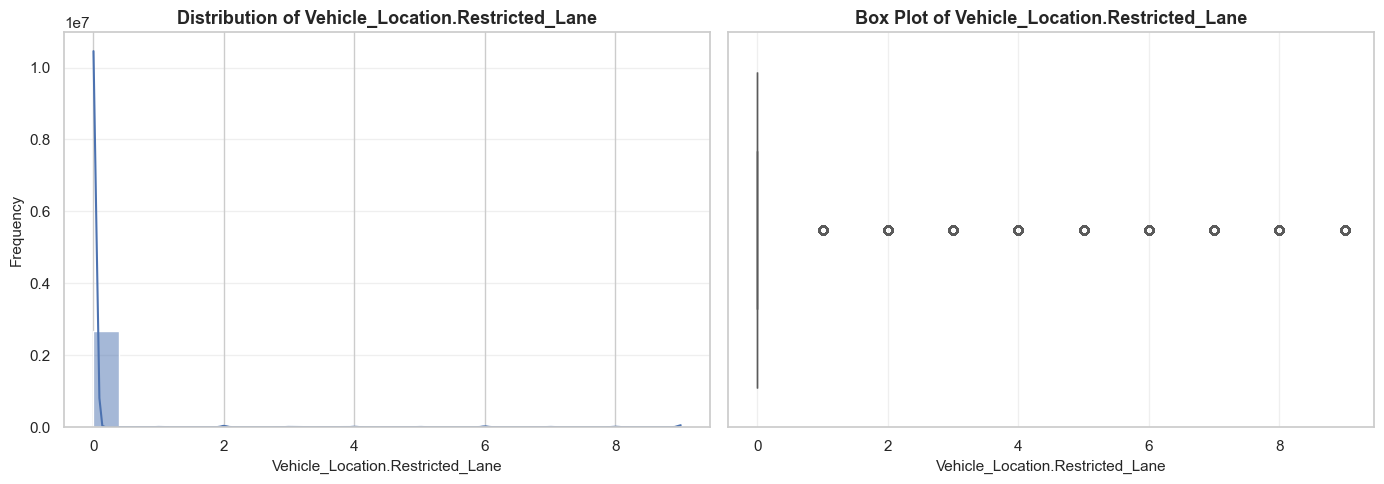

'Vehicle_Location.Restricted_Lane': skewness = 10.218 (highly skewed); 38,071 outlier(s) detected (1.4% of non-null values), using the 1.5 x IQR rule [0.0, 0.0].
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\numerical_Year_vehicle_distribution.png


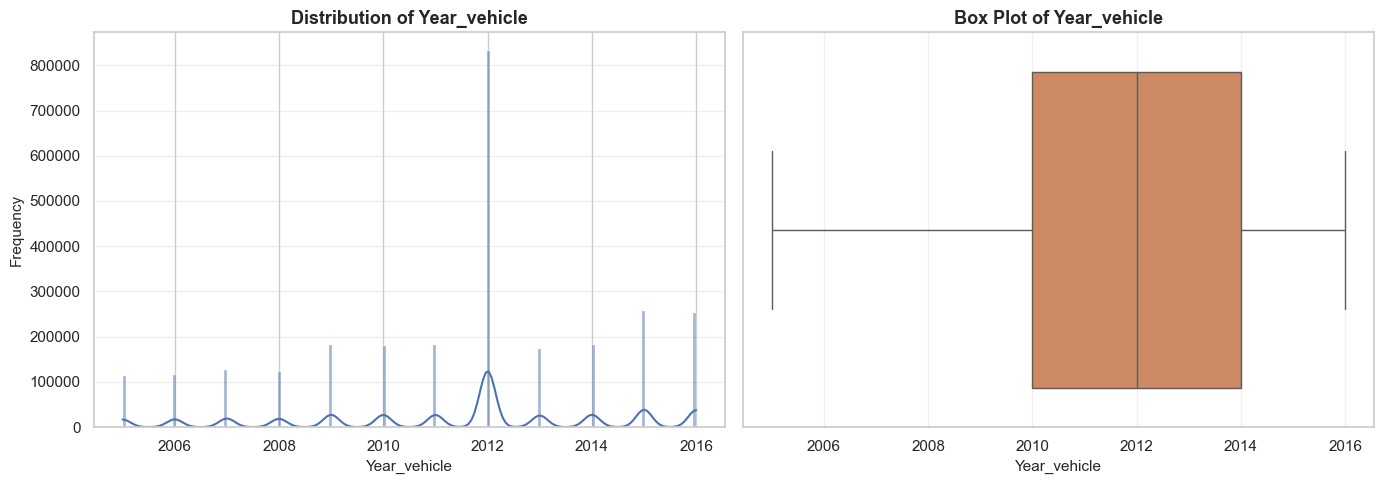

'Year_vehicle': skewness = -0.457 (approximately symmetric); 0 outlier(s) detected (0.0% of non-null values), using the 1.5 x IQR rule [2004.0, 2020.0].


In [9]:
def analyze_numerical_feature(df: pd.DataFrame, column: str) -> dict:
    '''
    Generate a histogram and box plot for a numerical column, save the
    figure, and compute skewness and IQR-based outlier diagnostics.

    Args:
        df (pd.DataFrame): The dataframe containing the column.
        column (str): Name of the numerical column to analyze.

    Returns:
        dict: Diagnostic statistics for the column (skew, outlier count/percentage,
              IQR bounds).
    '''
    series = df[column].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(series, kde=True, ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"Distribution of {column}", fontweight="bold")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", alpha=0.3)

    sns.boxplot(x=series, ax=axes[1], color="#DD8452")
    axes[1].set_title(f"Box Plot of {column}", fontweight="bold")
    axes[1].set_xlabel(column)
    axes[1].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    save_figure(fig, f"numerical_{column}_distribution.png")
    plt.show()

    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]

    stats = {
        "Column": column,
        "Skewness": round(series.skew(), 3),
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers),
        "Outlier Percentage (%)": round((len(outliers) / len(series)) * 100, 2) if len(series) else 0,
    }

    skew_value = stats["Skewness"]
    if abs(skew_value) < 0.5:
        skew_verdict = "approximately symmetric"
    elif abs(skew_value) < 1.0:
        skew_verdict = "moderately skewed"
    else:
        skew_verdict = "highly skewed"

    print(
        f"'{column}': skewness = {skew_value} ({skew_verdict}); "
        f"{stats['Outlier Count']:,} outlier(s) detected "
        f"({stats['Outlier Percentage (%)']}% of non-null values), "
        f"using the 1.5 x IQR rule [{stats['Lower Bound']}, {stats['Upper Bound']}]."
    )

    return stats


numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns detected: {numerical_columns}")
print()

numerical_diagnostics = []
for col in numerical_columns:
    numerical_diagnostics.append(analyze_numerical_feature(df, col))

numerical_diagnostics_df = pd.DataFrame(numerical_diagnostics)


In [10]:
numerical_diagnostics_df

,Column,Skewness,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,Did_Police_Officer_Attend_Scene_of_Accident,1.70,1.00,1.00,0.00,1.00,1.00,511592,18.84
1,Latitude,1.03,51.48,53.45,1.97,48.53,56.40,35921,1.32
2,Longitude,-0.39,-2.31,-0.21,2.11,-5.47,2.95,3554,0.13
3,Number_of_Vehicles,10.37,2.00,2.00,0.00,2.00,2.00,1053722,38.80
4,Pedestrian_Crossing-Human_Control,14.18,0.00,0.00,0.00,0.00,0.00,16211,0.60
5,Pedestrian_Crossing-Physical_Facilities,2.41,0.00,0.00,0.00,0.00,0.00,447411,16.47
6,Speed_limit,1.04,30.00,50.00,20.00,0.00,80.00,0,0.00
7,Year_accident,-0.04,"2,008.00","2,014.00",6.00,"1,999.00","2,023.00",0,0.00
8,Age_of_Vehicle,1.58,5.00,8.00,3.00,0.50,12.50,222267,8.18
9,Engine_Capacity_.CC.,6.66,"1,461.00","1,896.00",435.00,808.50,"2,548.50",328730,12.10


**Interpretation**

- **What it shows:** For every numerical column, the histogram reveals the shape of its
  distribution (symmetric, skewed, multi-modal), while the box plot summarizes its
  central tendency, spread, and any values falling outside the 1.5×IQR whiskers.
- **Why it matters:** Count-based fields (e.g., `Number_of_Vehicles`) are typically
  **right-skewed**, since most accidents involve only 1–2 vehicles while a small number
  involve many — this is a natural, expected pattern rather than a data quality issue.
  Geospatial fields (`Latitude`, `Longitude`) should show ranges consistent with the
  UK's geographic bounds; values far outside this range would indicate a data quality
  concern worth flagging (though not correcting here). Fields like `Speed_limit` are
  inherently discrete/coded (e.g., 20/30/40/50/60/70 mph) rather than continuous, so
  their "outliers" reflect legitimate but less common speed zones, not anomalies.
- **Impact on prediction:** Skewed numerical distributions and IQR-flagged outliers
  identified here directly inform **future** feature engineering decisions (e.g.,
  log-transformation for heavily skewed counts, or outlier-robust scaling), but per the
  scope of this notebook, **no transformation or removal is performed now** — this
  section is diagnostic only.


---
## 4. Categorical Feature Analysis

**Purpose:** Generate frequency-ranked count plots for the key categorical features
most relevant to accident severity prediction, to understand their distribution and
identify dominant categories.


In [11]:
def plot_categorical_distribution(df: pd.DataFrame, column: str, display_name: str, top_n: int = 15):
    '''
    Generate a frequency-ranked count plot for a categorical column and
    save the resulting figure.

    Args:
        df (pd.DataFrame): The dataframe containing the column.
        column (str): Name of the categorical column to plot.
        display_name (str): Human-readable name used in the chart title/labels.
        top_n (int): Maximum number of categories to display, ranked by frequency.

    Returns:
        pd.Series: Value counts for the column, ranked by frequency (descending).
    '''
    value_counts = df[column].value_counts().head(top_n)

    fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(value_counts))))

    sns.barplot(
        x=value_counts.values,
        y=value_counts.index.astype(str),
        hue=value_counts.index.astype(str),
        palette="viridis",
        legend=False,
        ax=ax,
    )

    total = len(df[column].dropna())
    for i, count in enumerate(value_counts.values):
        percentage = (count / total) * 100 if total else 0
        ax.annotate(
            f"{count:,} ({percentage:.1f}%)",
            (count, i),
            va="center", ha="left", fontsize=9, xytext=(5, 0),
            textcoords="offset points",
        )

    ax.set_title(f"Distribution of {display_name} (Ranked by Frequency)", fontweight="bold")
    ax.set_xlabel("Number of Records")
    ax.set_ylabel(display_name)
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    save_figure(fig, f"categorical_{column}_distribution.png")
    plt.show()

    return value_counts


### 4.1 Weather Conditions

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\categorical_Weather_Conditions_distribution.png


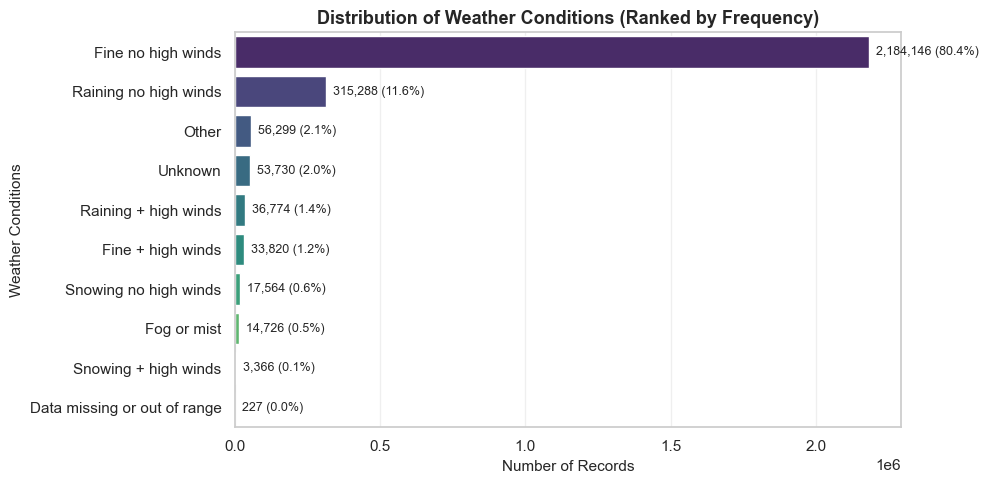

In [12]:
if column_exists(df, "Weather_Conditions"):
    plot_categorical_distribution(df, "Weather_Conditions", "Weather Conditions")


**Interpretation**

- **What it shows:** The most frequently recorded weather conditions at the time of
  accidents, ranked from most to least common.
- **Why it matters:** Most accidents are expected to occur under "fine, no high winds"
  conditions — not because good weather is more dangerous, but because the vast
  majority of all driving occurs in fair weather, so raw counts are dominated by
  exposure/volume rather than risk-per-trip.
- **Impact on prediction:** Weather is a plausible situational driver of severity (e.g.,
  poor visibility or wet/icy roads can increase impact severity), but its raw frequency
  distribution alone doesn't establish that relationship — Section 6 (Severity
  Relationship Analysis) examines weather **against** severity directly to explore this.


### 4.2 Road Surface Conditions

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\categorical_Road_Surface_Conditions_distribution.png


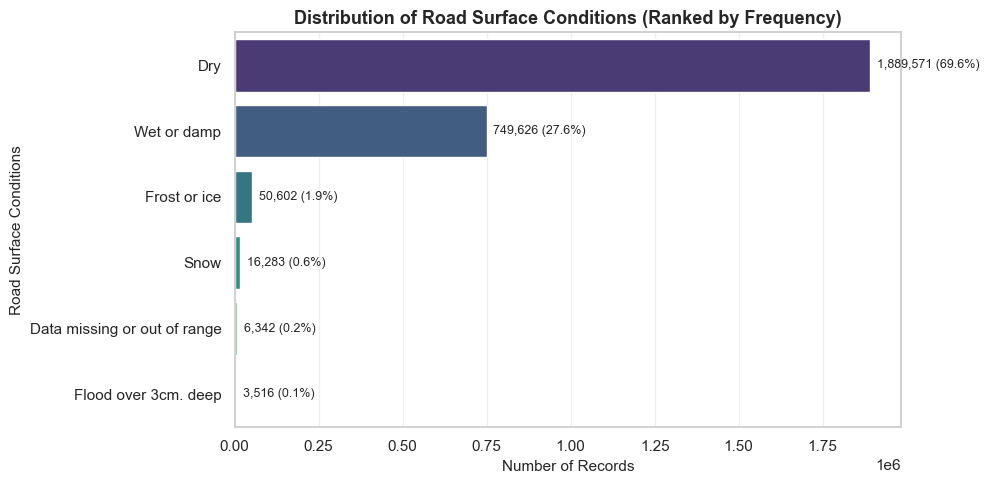

In [13]:
if column_exists(df, "Road_Surface_Conditions"):
    plot_categorical_distribution(df, "Road_Surface_Conditions", "Road Surface Conditions")


**Interpretation**

- **What it shows:** The relative frequency of dry, wet/damp, icy, and other road
  surface conditions across recorded accidents.
- **Why it matters:** Road surface condition directly affects vehicle traction and
  stopping distance, making it a mechanistically plausible contributor to accident
  severity, independent of weather (e.g., a road can remain wet after rain has stopped).
- **Impact on prediction:** This feature is a strong candidate for retention in the
  final feature set, and its interaction with `Speed_limit` and `Road_Type` should be
  explored further in feature engineering.


### 4.3 Road Type

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\categorical_Road_Type_distribution.png


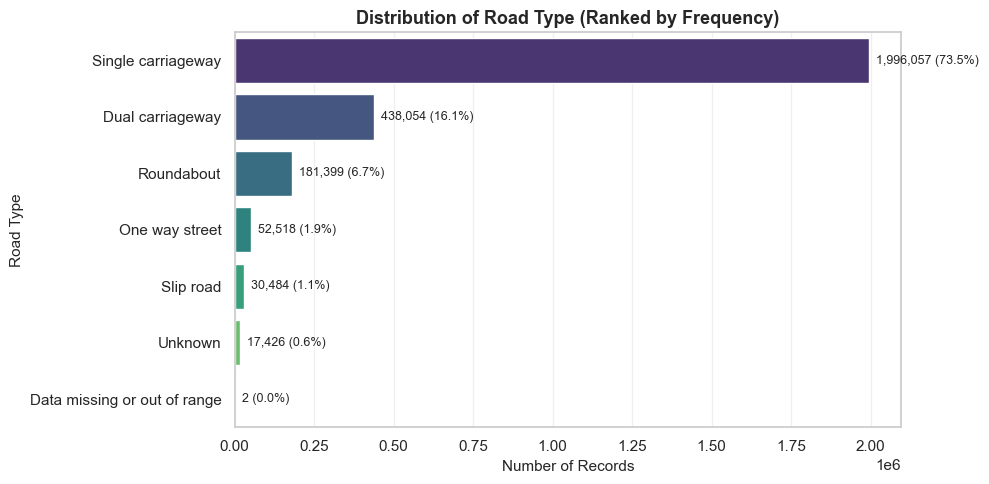

In [14]:
if column_exists(df, "Road_Type"):
    plot_categorical_distribution(df, "Road_Type", "Road Type")


**Interpretation**

- **What it shows:** The distribution of accidents across road types (e.g., single
  carriageway, dual carriageway, roundabout).
- **Why it matters:** Different road types carry structurally different risk profiles —
  single carriageways often permit higher closing speeds between opposing traffic,
  while roundabouts typically enforce lower speeds but more frequent give-way
  interactions.
- **Impact on prediction:** Road type is likely to correlate with both speed limit and
  severity, and is a strong candidate categorical predictor for the eventual model.


### 4.4 Light Conditions

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\categorical_Light_Conditions_distribution.png


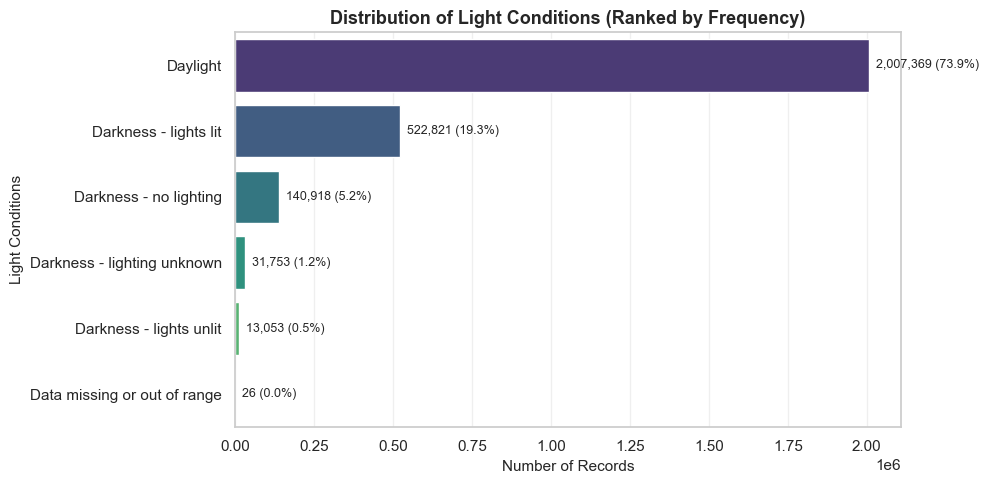

In [15]:
if column_exists(df, "Light_Conditions"):
    plot_categorical_distribution(df, "Light_Conditions", "Light Conditions")


**Interpretation**

- **What it shows:** The proportion of accidents occurring in daylight versus various
  darkness conditions (with or without street lighting).
- **Why it matters:** Reduced visibility during darkness is a well-established road
  safety risk factor, particularly for pedestrian and cyclist involvement.
- **Impact on prediction:** Combined with `Urban_or_Rural_Area`, this feature can help
  distinguish higher-risk unlit rural night-time driving from well-lit urban night-time
  conditions, both of which fall under "darkness" but carry different severity risk.


### 4.5 Junction Detail

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\categorical_Junction_Detail_distribution.png


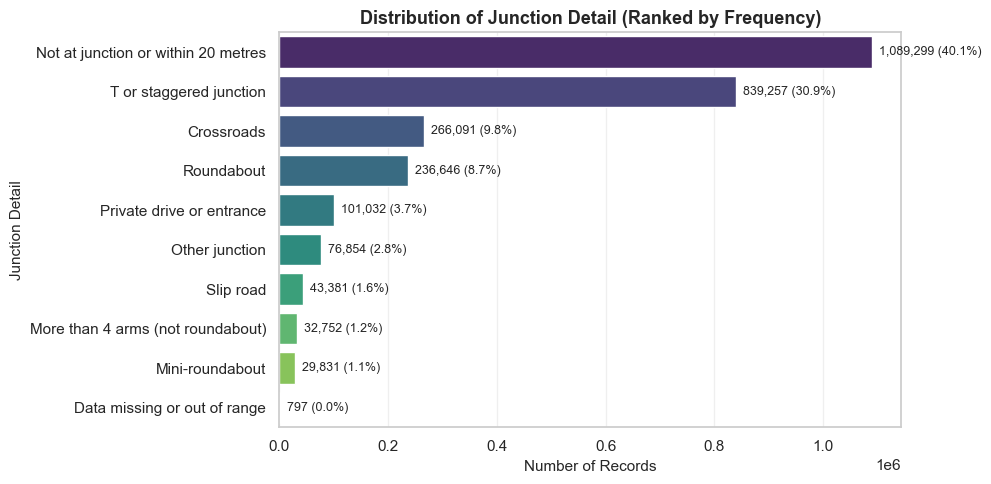

In [16]:
if column_exists(df, "Junction_Detail"):
    plot_categorical_distribution(df, "Junction_Detail", "Junction Detail")


**Interpretation**

- **What it shows:** The frequency of different junction configurations (e.g., no
  junction nearby, crossroads, T-junctions, roundabouts) at accident locations.
- **Why it matters:** Junctions concentrate conflicting vehicle paths and are common
  sites of angled, side-impact collisions, which can differ in severity profile from
  single-vehicle or rear-end collisions on open road.
- **Impact on prediction:** Junction configuration is a structurally meaningful
  predictor of collision type and, by extension, likely severity.


### 4.6 Urban or Rural Area

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\categorical_Urban_or_Rural_Area_distribution.png


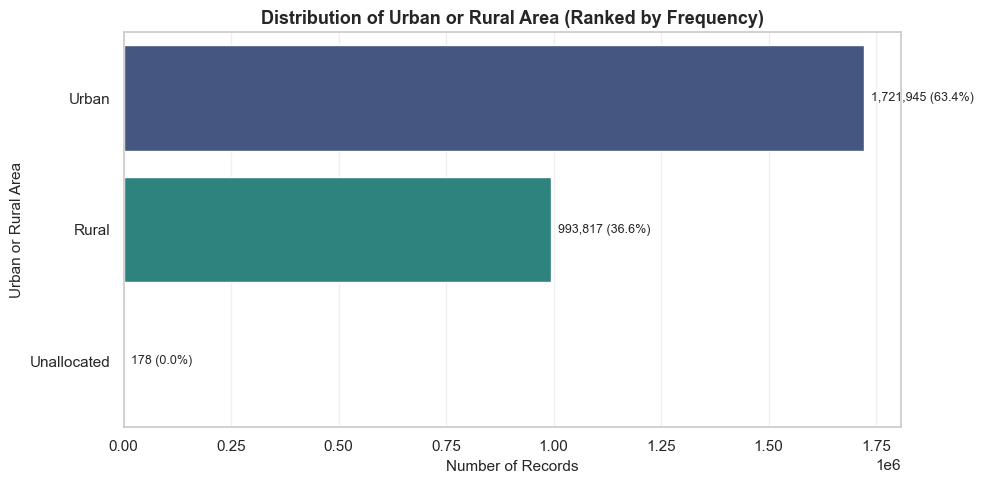

In [17]:
if column_exists(df, "Urban_or_Rural_Area"):
    plot_categorical_distribution(df, "Urban_or_Rural_Area", "Urban or Rural Area")


**Interpretation**

- **What it shows:** The split between accidents occurring in urban versus rural areas.
- **Why it matters:** Urban areas typically have far more traffic exposure (and
  therefore raw accident counts), but rural roads are frequently associated with
  **higher-severity** outcomes per accident, due to higher speed limits, longer
  emergency response times, and less forgiving roadside environments.
- **Impact on prediction:** This is one of the most consistently important features in
  published road-safety severity research and should be prioritized in feature
  engineering and modeling.


### 4.7 Speed Limit

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\categorical_Speed_limit_distribution.png


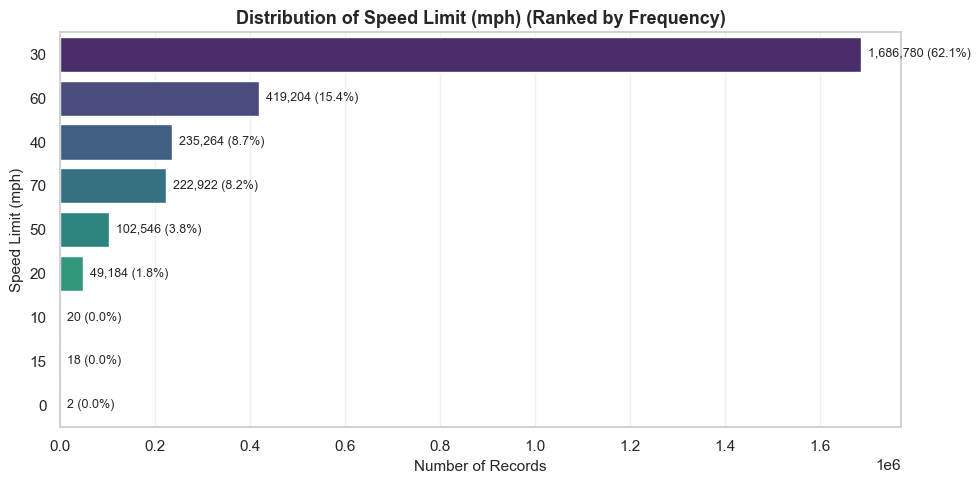

In [18]:
if column_exists(df, "Speed_limit"):
    plot_categorical_distribution(df, "Speed_limit", "Speed Limit (mph)")


**Interpretation**

- **What it shows:** The distribution of posted speed limits at accident locations,
  ranked by frequency.
- **Why it matters:** Although stored numerically, `Speed_limit` in UK STATS19 data is
  effectively a small set of discrete, regulatory speed zones (e.g., 20/30/40/50/60/70
  mph) rather than a continuous measurement, making a ranked count plot an appropriate
  and informative view alongside its numerical treatment in Section 3.
- **Impact on prediction:** Higher speed limits are physically linked to greater
  collision energy and are widely reported in road safety literature as one of the
  strongest predictors of fatal and serious outcomes.


### 4.8 Vehicle Type

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\categorical_Vehicle_Type_distribution.png


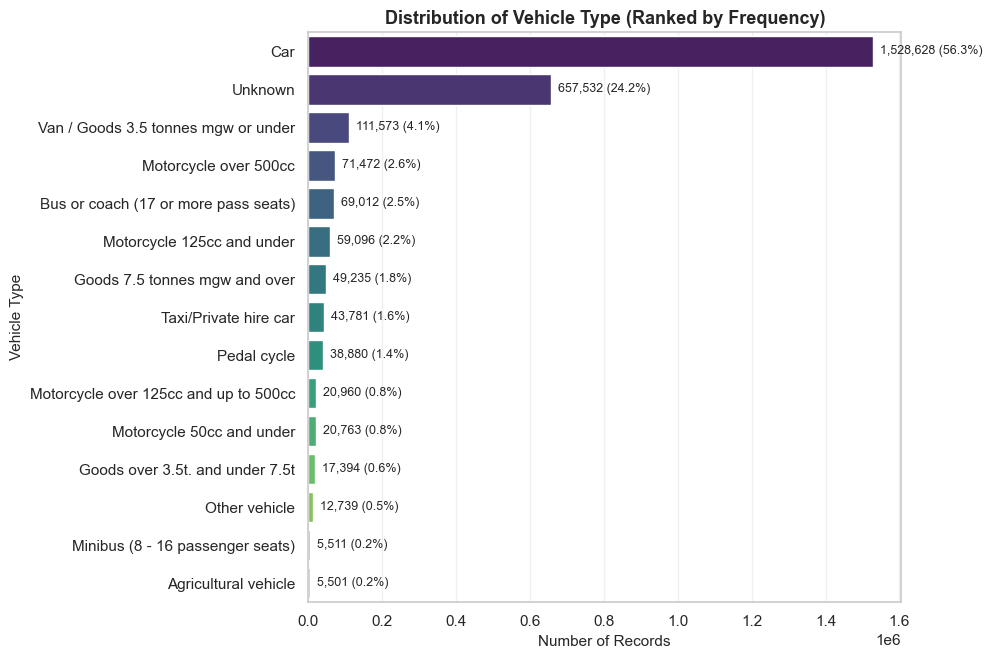

In [19]:
if column_exists(df, "Vehicle_Type"):
    plot_categorical_distribution(df, "Vehicle_Type", "Vehicle Type")


**Interpretation**

- **What it shows:** The relative frequency of different vehicle types (e.g., car,
  motorcycle, van, bus) involved in recorded accidents.
- **Why it matters:** Vehicle type strongly influences occupant protection level —
  motorcyclists and cyclists face dramatically higher injury severity risk than
  occupants of cars or larger vehicles in a comparable collision.
- **Impact on prediction:** Vehicle type is expected to be one of the more
  discriminative categorical features for severity, and its interaction with
  `Road_Type` and `Speed_limit` merits particular attention in feature engineering.


---
## 5. Time-Based Analysis

**Purpose:** Analyze accident frequency across year, month, day of week, and hour of
day to understand temporal traffic and risk patterns.

> **Note:** Month and hour-of-day groupings shown below are derived **transiently**,
> in memory, purely for visualization in this notebook. They are **not** written back
> to the dataset or persisted anywhere — deriving permanent new feature columns is
> explicitly out of scope for this EDA notebook and is deferred to feature engineering.


### 5.1 Accidents by Year

In [20]:
if column_exists(df, "Year"):
    year_counts = df["Year"].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(year_counts.index.astype(str), year_counts.values, marker="o", linewidth=2, color="#4C72B0")
    for x, y in zip(year_counts.index.astype(str), year_counts.values):
        ax.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

    ax.set_title("Number of Accidents by Year", fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Accidents")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    save_figure(fig, "time_accidents_by_year.png")
    plt.show()


[SKIPPED] Column 'Year' was not found in the cleaned dataset.


**Interpretation**

- **What it shows:** The year-over-year trend in the total number of recorded
  accidents.
- **Why it matters:** Long-term trends can reflect genuine changes in road safety
  (improved vehicle safety standards, infrastructure investment, enforcement) as well
  as external shocks (e.g., a sharp dip may reflect reduced traffic volume during an
  unusual year rather than safer roads).
- **Impact on prediction:** If severity patterns shift meaningfully across years, `Year`
  may be a useful control feature, or the modeling strategy may need to account for
  temporal drift (e.g., via time-aware validation splits).


### 5.2 Accidents by Month

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\time_accidents_by_month.png


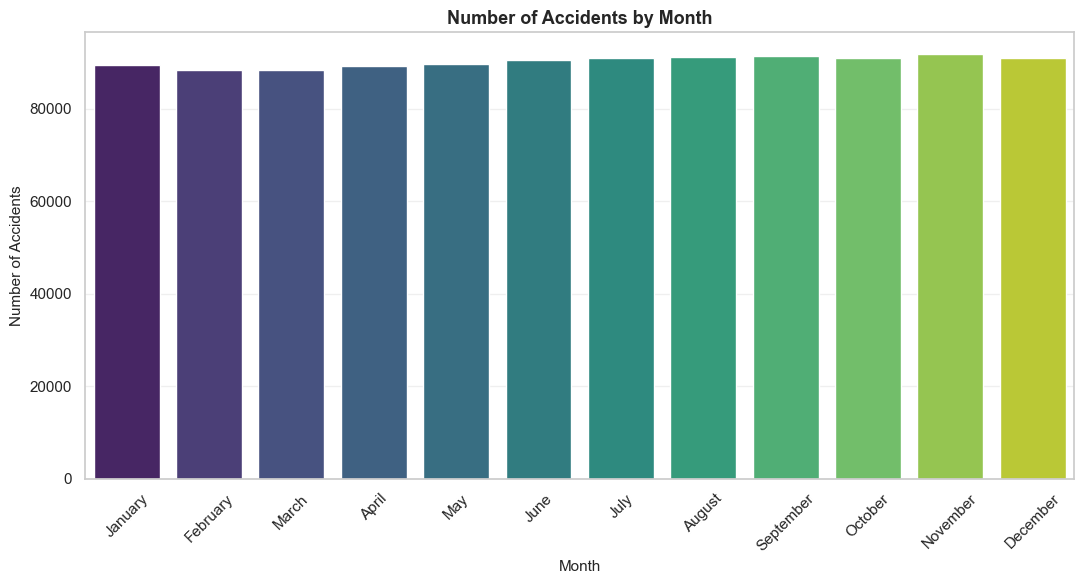

In [21]:
if column_exists(df, "Date"):
    month_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ]
    month_series = df["Date"].dt.month_name()
    month_counts = month_series.value_counts().reindex(month_order).dropna()

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.barplot(x=month_counts.index, y=month_counts.values, hue=month_counts.index,
                palette="viridis", legend=False, ax=ax)

    ax.set_title("Number of Accidents by Month", fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Number of Accidents")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    save_figure(fig, "time_accidents_by_month.png")
    plt.show()
else:
    print("[SKIPPED] 'Date' column not available for month-level analysis.")


**Interpretation**

- **What it shows:** Seasonal variation in accident frequency across calendar months.
- **Why it matters:** Autumn and winter months are commonly associated with increased
  accident counts in the UK due to reduced daylight hours, adverse weather (rain, fog,
  ice), and holiday-period travel surges.
- **Impact on prediction:** If a clear seasonal pattern exists, a derived "season" or
  "month" feature (built later, in Phase 5) could meaningfully improve model
  performance by capturing weather- and daylight-correlated risk that isn't fully
  explained by `Weather_Conditions` or `Light_Conditions` alone.


### 5.3 Accidents by Day of Week

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\time_accidents_by_day_of_week.png


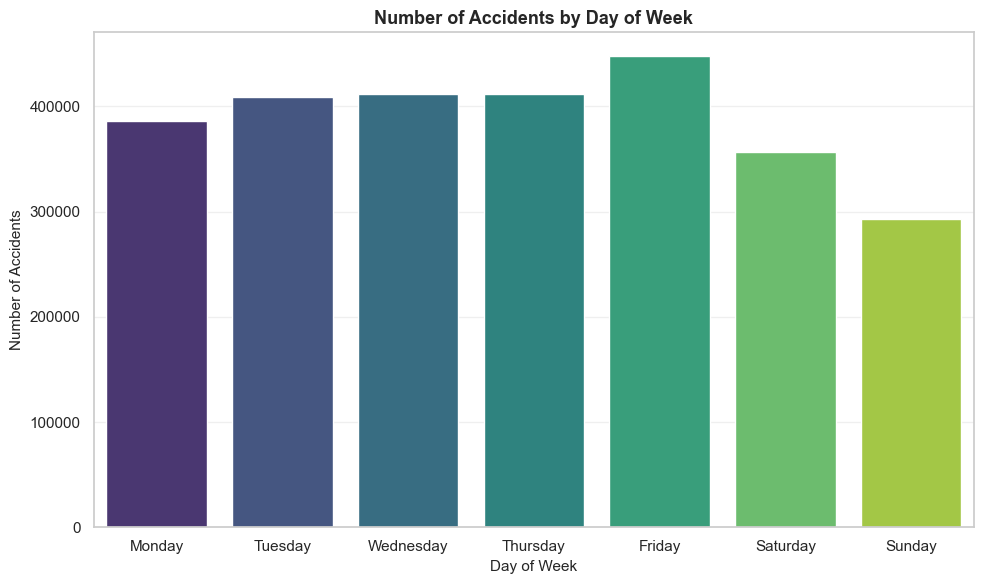

In [22]:
if column_exists(df, "Day_of_Week"):
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    day_counts = df["Day_of_Week"].value_counts().reindex(day_order).dropna()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=day_counts.index, y=day_counts.values, hue=day_counts.index,
                palette="viridis", legend=False, ax=ax)

    ax.set_title("Number of Accidents by Day of Week", fontweight="bold")
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Number of Accidents")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    save_figure(fig, "time_accidents_by_day_of_week.png")
    plt.show()


**Interpretation**

- **What it shows:** How accident frequency is distributed across the seven days of
  the week.
- **Why it matters:** Weekday patterns typically reflect commuter traffic peaks, while
  weekend patterns (especially Friday/Saturday nights) are often associated with
  leisure travel and, in some datasets, higher-severity outcomes linked to nighttime
  driving.
- **Impact on prediction:** A consistent weekday-vs-weekend distinction — and
  particularly whether weekend accidents skew toward higher severity — would support
  including day-of-week (or a binary weekend flag) as a predictive feature.


### 5.4 Accidents by Hour of Day

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\time_accidents_by_hour.png


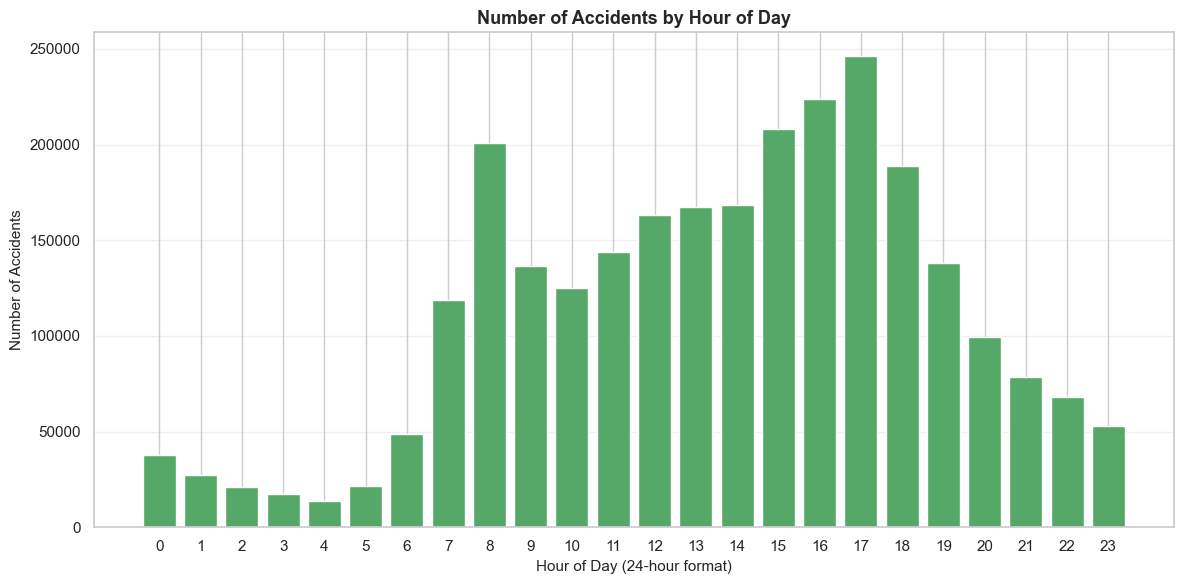

In [23]:
def extract_hour(time_value):
    '''
    Safely extract the hour component from a value that may be a
    datetime.time object, a string, or missing/NaT.

    Args:
        time_value: The value to extract an hour from.

    Returns:
        int or np.nan: The hour (0-23), or np.nan if extraction is not possible.
    '''
    if pd.isnull(time_value):
        return np.nan
    if hasattr(time_value, "hour"):
        return time_value.hour
    try:
        return pd.to_datetime(time_value, errors="coerce").hour
    except (TypeError, ValueError):
        return np.nan


if column_exists(df, "Time"):
    hour_series = df["Time"].apply(extract_hour)
    hour_counts = hour_series.value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(hour_counts.index, hour_counts.values, color="#55A868")

    ax.set_title("Number of Accidents by Hour of Day", fontweight="bold")
    ax.set_xlabel("Hour of Day (24-hour format)")
    ax.set_ylabel("Number of Accidents")
    ax.set_xticks(range(0, 24))
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    save_figure(fig, "time_accidents_by_hour.png")
    plt.show()


**Interpretation**

- **What it shows:** The distribution of accidents by hour of day, typically revealing
  peaks around the morning (approx. 08:00) and evening (approx. 16:00-18:00) commute
  windows.
- **Why it matters:** These peaks primarily reflect traffic **volume** (rush-hour
  exposure) rather than necessarily higher per-trip risk; late-night hours, while lower
  in absolute accident count, are frequently associated with disproportionately
  **severe** outcomes due to higher speeds, fatigue, and impairment.
- **Impact on prediction:** This suggests hour-of-day may have a **non-linear**
  relationship with severity (as opposed to raw frequency), reinforcing the value of
  examining severity directly against time-based groupings, not just raw counts, in
  future modeling.


---
## 6. Severity Relationship Analysis

**Purpose:** Examine how `Accident_Severity` is distributed **within** each category of
key situational features, using normalized stacked bar charts, to identify which
factors are associated with a higher proportion of severe outcomes.


In [24]:
def plot_severity_relationship(df: pd.DataFrame, column: str, display_name: str, top_n: int = 12):
    '''
    Plot a normalized, stacked bar chart showing the proportion of each
    Accident_Severity class within every category of a given column.

    Args:
        df (pd.DataFrame): The dataframe containing the column and target.
        column (str): Name of the categorical (or discrete numeric) column to relate to severity.
        display_name (str): Human-readable name used in the chart title/labels.
        top_n (int): Maximum number of categories (by overall frequency) to display.

    Returns:
        pd.DataFrame: The underlying cross-tabulated percentage table.
    '''
    top_categories = df[column].value_counts().head(top_n).index
    subset = df[df[column].isin(top_categories)]

    crosstab = pd.crosstab(subset[column], subset[TARGET_COLUMN], normalize="index") * 100
    crosstab = crosstab.loc[
        subset[column].value_counts().reindex(crosstab.index).sort_values(ascending=False).index
    ]

    fig, ax = plt.subplots(figsize=(11, max(5, 0.5 * len(crosstab))))
    crosstab.plot(kind="barh", stacked=True, colormap="viridis", ax=ax)

    ax.set_title(f"Accident Severity Composition by {display_name}", fontweight="bold")
    ax.set_xlabel("Percentage of Accidents (%)")
    ax.set_ylabel(display_name)
    ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    save_figure(fig, f"severity_by_{column}.png")
    plt.show()

    return crosstab


### 6.1 Severity by Weather Conditions

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\severity_by_Weather_Conditions.png


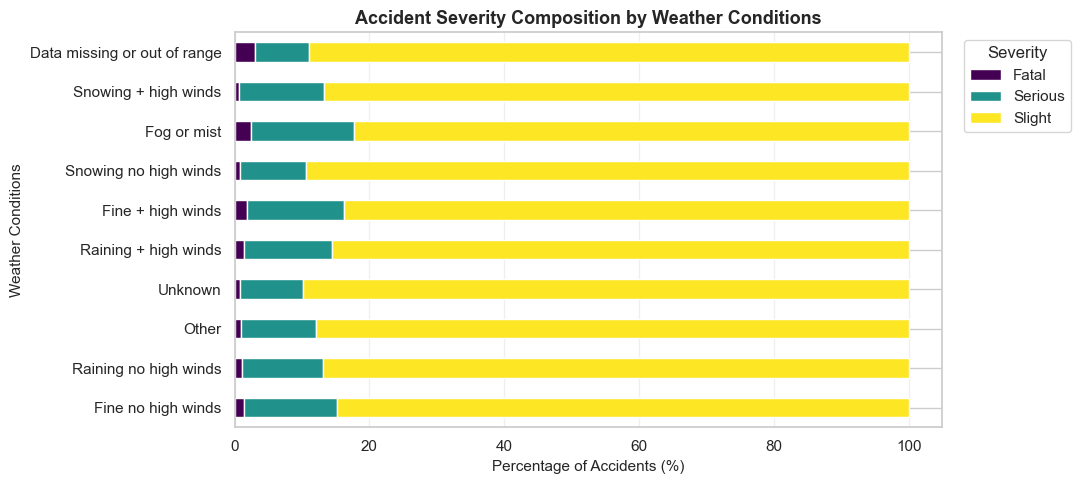

In [25]:
if column_exists(df, "Weather_Conditions"):
    plot_severity_relationship(df, "Weather_Conditions", "Weather Conditions")


**Interpretation:** If `Fatal`/`Serious` proportions rise under adverse weather
(rain, fog, snow) relative to fine conditions, this supports weather as a genuine
severity-modifying factor rather than merely a volume driver — an important distinction
from the raw frequency view in Section 4.1.


### 6.2 Severity by Road Surface

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\severity_by_Road_Surface_Conditions.png


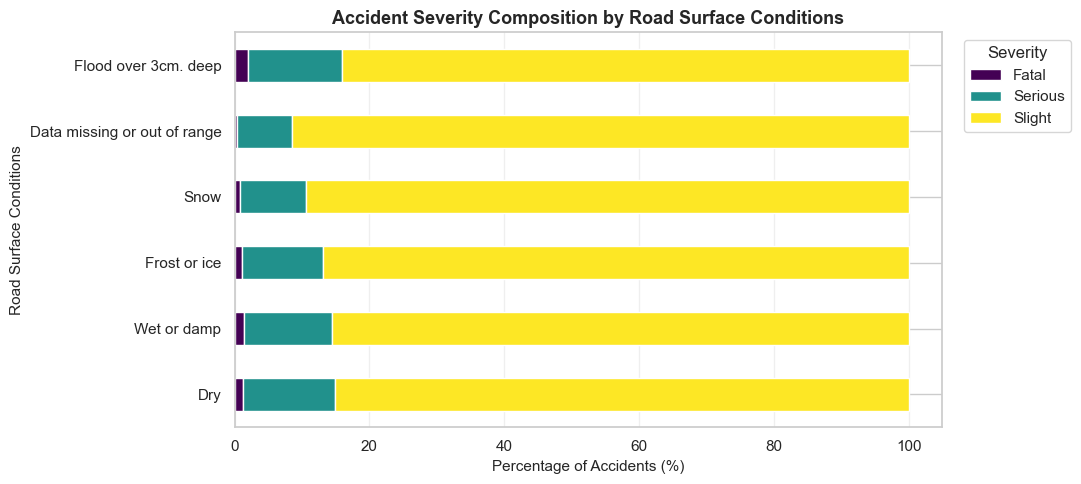

In [26]:
if column_exists(df, "Road_Surface_Conditions"):
    plot_severity_relationship(df, "Road_Surface_Conditions", "Road Surface Conditions")


**Interpretation:** A higher share of severe outcomes on wet, icy, or otherwise
compromised surfaces would reinforce road surface condition as a mechanistically
plausible severity predictor (reduced traction increasing impact severity), separate
from its raw frequency distribution.


### 6.3 Severity by Road Type

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\severity_by_Road_Type.png


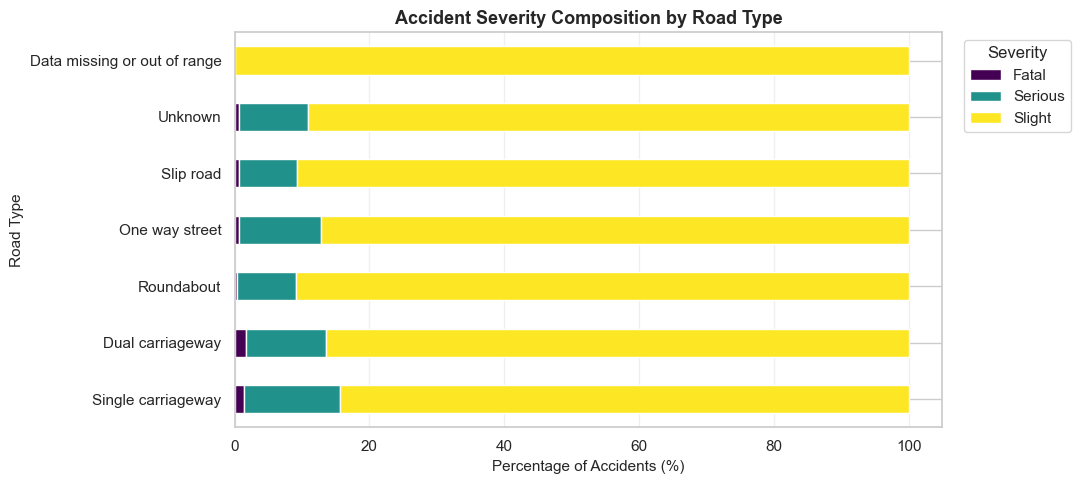

In [27]:
if column_exists(df, "Road_Type"):
    plot_severity_relationship(df, "Road_Type", "Road Type")


**Interpretation:** Road types associated with higher closing speeds (e.g.,
single/dual carriageways) would be expected to show a larger share of `Serious`/`Fatal`
outcomes than lower-speed road types such as roundabouts, given the direct relationship
between impact speed and injury severity.


### 6.4 Severity by Speed Limit

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\severity_by_Speed_limit.png


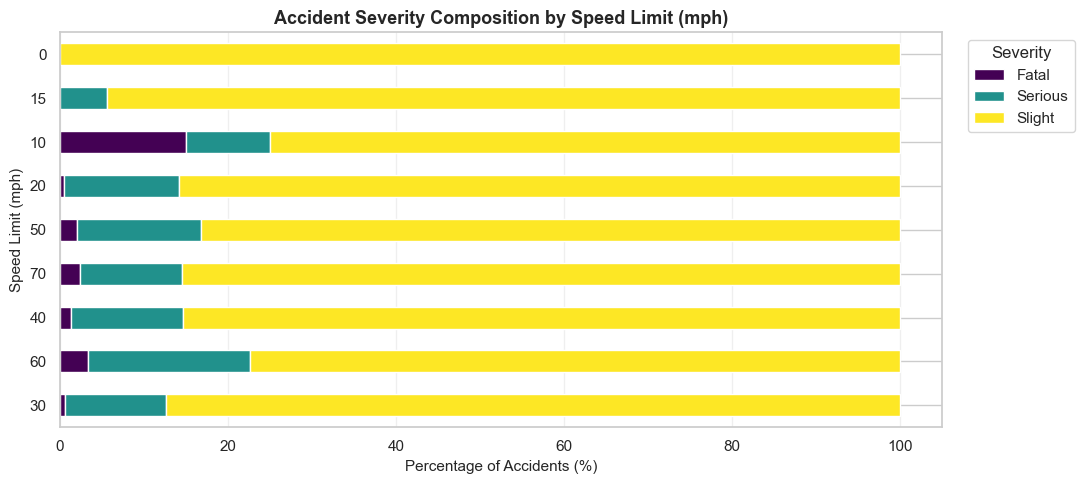

In [28]:
if column_exists(df, "Speed_limit"):
    plot_severity_relationship(df, "Speed_limit", "Speed Limit (mph)")


**Interpretation:** This is one of the most important relationships to examine —
a clear upward trend in `Fatal`/`Serious` share as speed limit increases would strongly
corroborate the physics-based expectation that higher-energy collisions produce more
severe outcomes, and would elevate `Speed_limit` as a high-priority modeling feature.


### 6.5 Severity by Light Conditions

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\severity_by_Light_Conditions.png


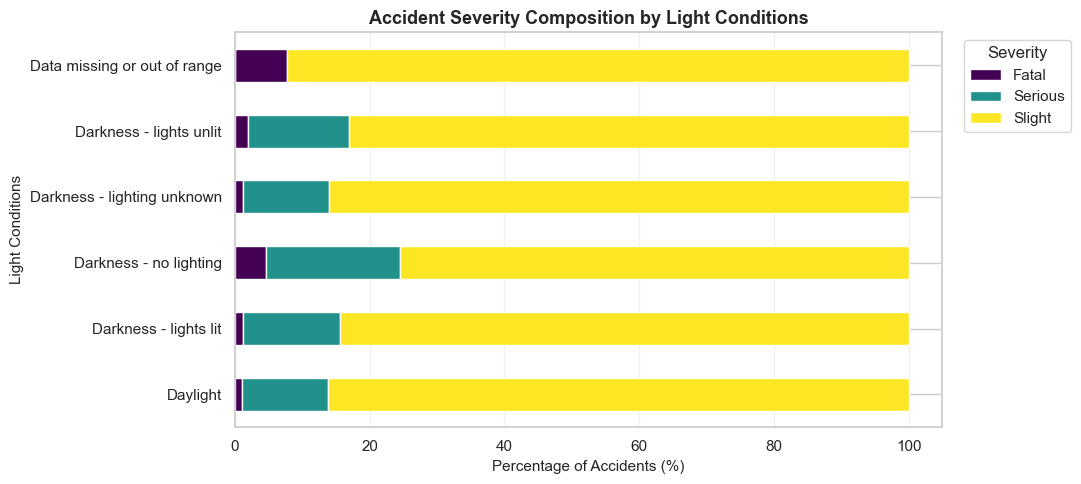

In [29]:
if column_exists(df, "Light_Conditions"):
    plot_severity_relationship(df, "Light_Conditions", "Light Conditions")


**Interpretation:** A higher severe-outcome share under darkness (especially
unlit darkness) versus daylight would support the well-documented visibility-related
risk of night-time driving, and would suggest interaction effects between
`Light_Conditions` and `Urban_or_Rural_Area` are worth exploring in feature engineering.


### 6.6 Severity by Junction Control

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\severity_by_Junction_Control.png


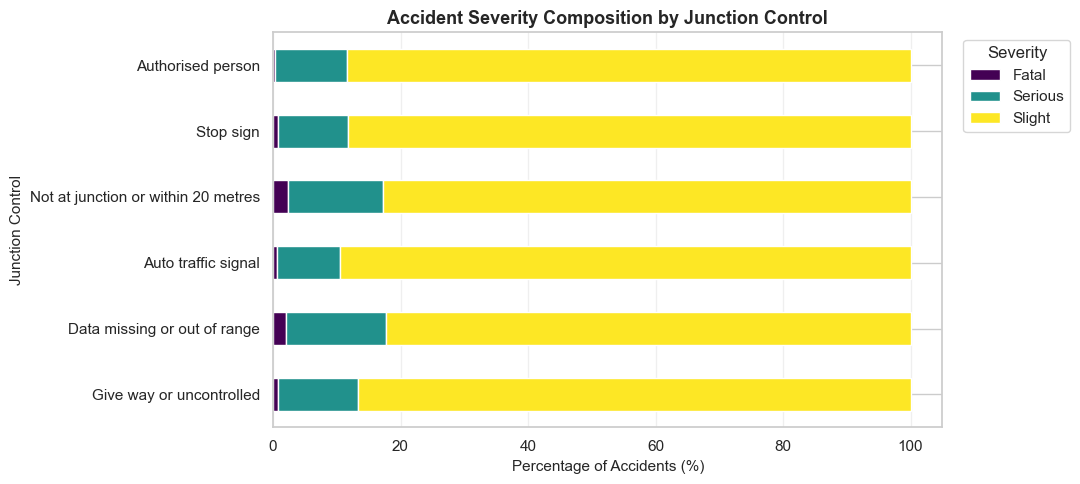

In [30]:
if column_exists(df, "Junction_Control"):
    plot_severity_relationship(df, "Junction_Control", "Junction Control")


**Interpretation:** Uncontrolled or give-way junctions might show a different
severity profile than signal-controlled junctions, reflecting differences in how
right-of-way ambiguity and stopping behavior affect collision dynamics.


### 6.7 Severity by Urban or Rural Area

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\severity_by_Urban_or_Rural_Area.png


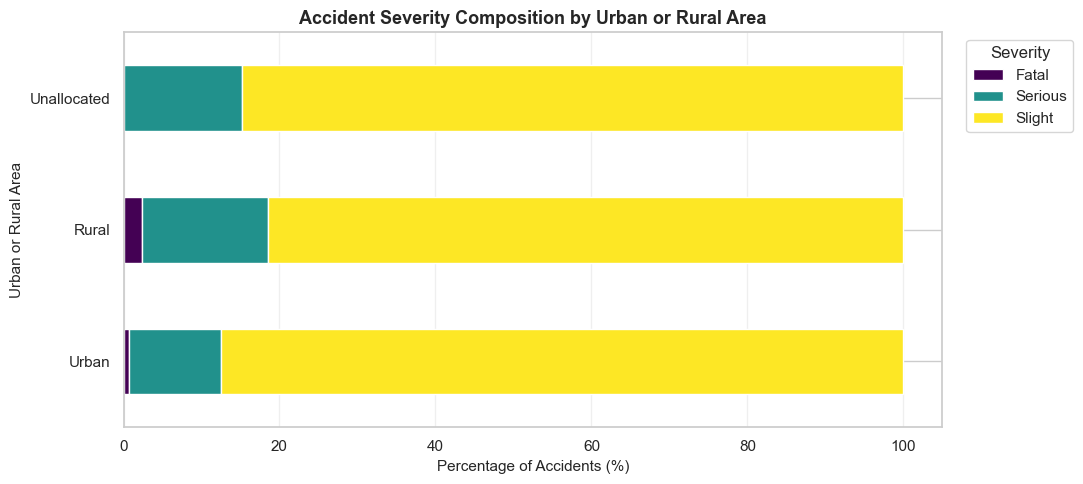

In [31]:
if column_exists(df, "Urban_or_Rural_Area"):
    plot_severity_relationship(df, "Urban_or_Rural_Area", "Urban or Rural Area")


**Interpretation:** Rural accidents are widely expected to show a
disproportionately higher share of `Serious`/`Fatal` outcomes than urban accidents, even
though urban areas have far more accidents overall — driven by higher rural speed
limits, longer emergency response times, and less forgiving road environments. This is
frequently one of the single strongest severity predictors in this dataset.


---
## 7. Correlation Analysis

**Purpose:** Generate a correlation heatmap across all numerical features to identify
strongly related variables, which is useful context for later feature selection and
multicollinearity awareness.


Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\correlation_heatmap_numerical_features.png


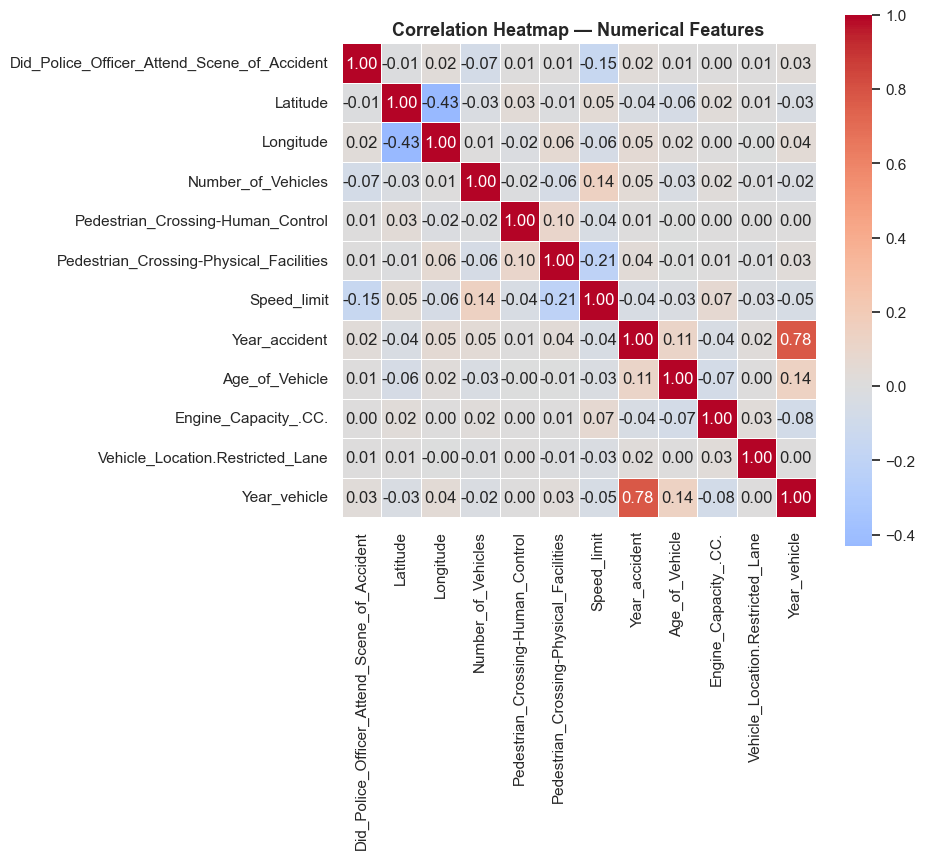

In [32]:
numerical_df = df.select_dtypes(include=np.number)

if numerical_df.shape[1] >= 2:
    correlation_matrix = numerical_df.corr()

    fig, ax = plt.subplots(figsize=(max(8, 0.8 * len(correlation_matrix.columns)),
                                     max(6, 0.8 * len(correlation_matrix.columns))))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )
    ax.set_title("Correlation Heatmap — Numerical Features", fontweight="bold")

    plt.tight_layout()
    save_figure(fig, "correlation_heatmap_numerical_features.png")
    plt.show()
else:
    print("[SKIPPED] Fewer than 2 numerical columns available for a correlation heatmap.")
    correlation_matrix = numerical_df.corr()


In [33]:
# Programmatically identify notably correlated pairs (|correlation| >= 0.5),
# excluding the trivial self-correlation diagonal.
HIGH_CORRELATION_THRESHOLD = 0.5

correlated_pairs = []
columns = correlation_matrix.columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) >= HIGH_CORRELATION_THRESHOLD:
            correlated_pairs.append(
                {"Feature 1": columns[i], "Feature 2": columns[j], "Correlation": round(corr_value, 3)}
            )

correlated_pairs_df = pd.DataFrame(correlated_pairs).sort_values(
    "Correlation", key=abs, ascending=False
) if correlated_pairs else pd.DataFrame(columns=["Feature 1", "Feature 2", "Correlation"])

print(f"Feature pairs with |correlation| >= {HIGH_CORRELATION_THRESHOLD}: {len(correlated_pairs_df)}")
correlated_pairs_df


Feature pairs with |correlation| >= 0.5: 1


,Feature 1,Feature 2,Correlation
0,Year_accident,Year_vehicle,0.78


**Interpretation**

- **What it shows:** Pairwise linear (Pearson) correlation coefficients between all
  numerical features, and an automatically filtered table of pairs exceeding a
  |correlation| ≥ 0.5 threshold.
- **Why it matters:** Highly correlated numerical features (e.g., geographically
  co-located `Latitude`/`Longitude` clusters, or two measurements capturing overlapping
  information) can introduce multicollinearity, which affects the interpretability of
  linear models (though tree-based models are generally more robust to it).
- **Impact on prediction:** Any pairs identified above should be reviewed during feature
  engineering to decide whether both should be retained, combined, or whether one is
  redundant — but **no feature is removed or transformed in this notebook**.


---
## 8. Outlier Analysis

**Purpose:** Consolidate a dedicated outlier analysis across all numerical features,
using the 1.5×IQR rule, presented as both a summary table and a combined visual grid.
**No outliers are removed or modified** — this section is purely diagnostic, building
directly on the per-feature statistics computed in Section 3.


In [34]:
outlier_summary = numerical_diagnostics_df[
    ["Column", "Q1", "Q3", "IQR", "Lower Bound", "Upper Bound", "Outlier Count", "Outlier Percentage (%)"]
].sort_values("Outlier Percentage (%)", ascending=False).reset_index(drop=True)

outlier_summary


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,Number_of_Vehicles,2.00,2.00,0.00,2.00,2.00,1053722,38.80
1,Did_Police_Officer_Attend_Scene_of_Accident,1.00,1.00,0.00,1.00,1.00,511592,18.84
2,Pedestrian_Crossing-Physical_Facilities,0.00,0.00,0.00,0.00,0.00,447411,16.47
3,Engine_Capacity_.CC.,"1,461.00","1,896.00",435.00,808.50,"2,548.50",328730,12.10
4,Age_of_Vehicle,5.00,8.00,3.00,0.50,12.50,222267,8.18
5,Vehicle_Location.Restricted_Lane,0.00,0.00,0.00,0.00,0.00,38071,1.40
6,Latitude,51.48,53.45,1.97,48.53,56.40,35921,1.32
7,Pedestrian_Crossing-Human_Control,0.00,0.00,0.00,0.00,0.00,16211,0.60
8,Longitude,-2.31,-0.21,2.11,-5.47,2.95,3554,0.13
9,Speed_limit,30.00,50.00,20.00,0.00,80.00,0,0.00


Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\outlier_analysis_combined_boxplots.png


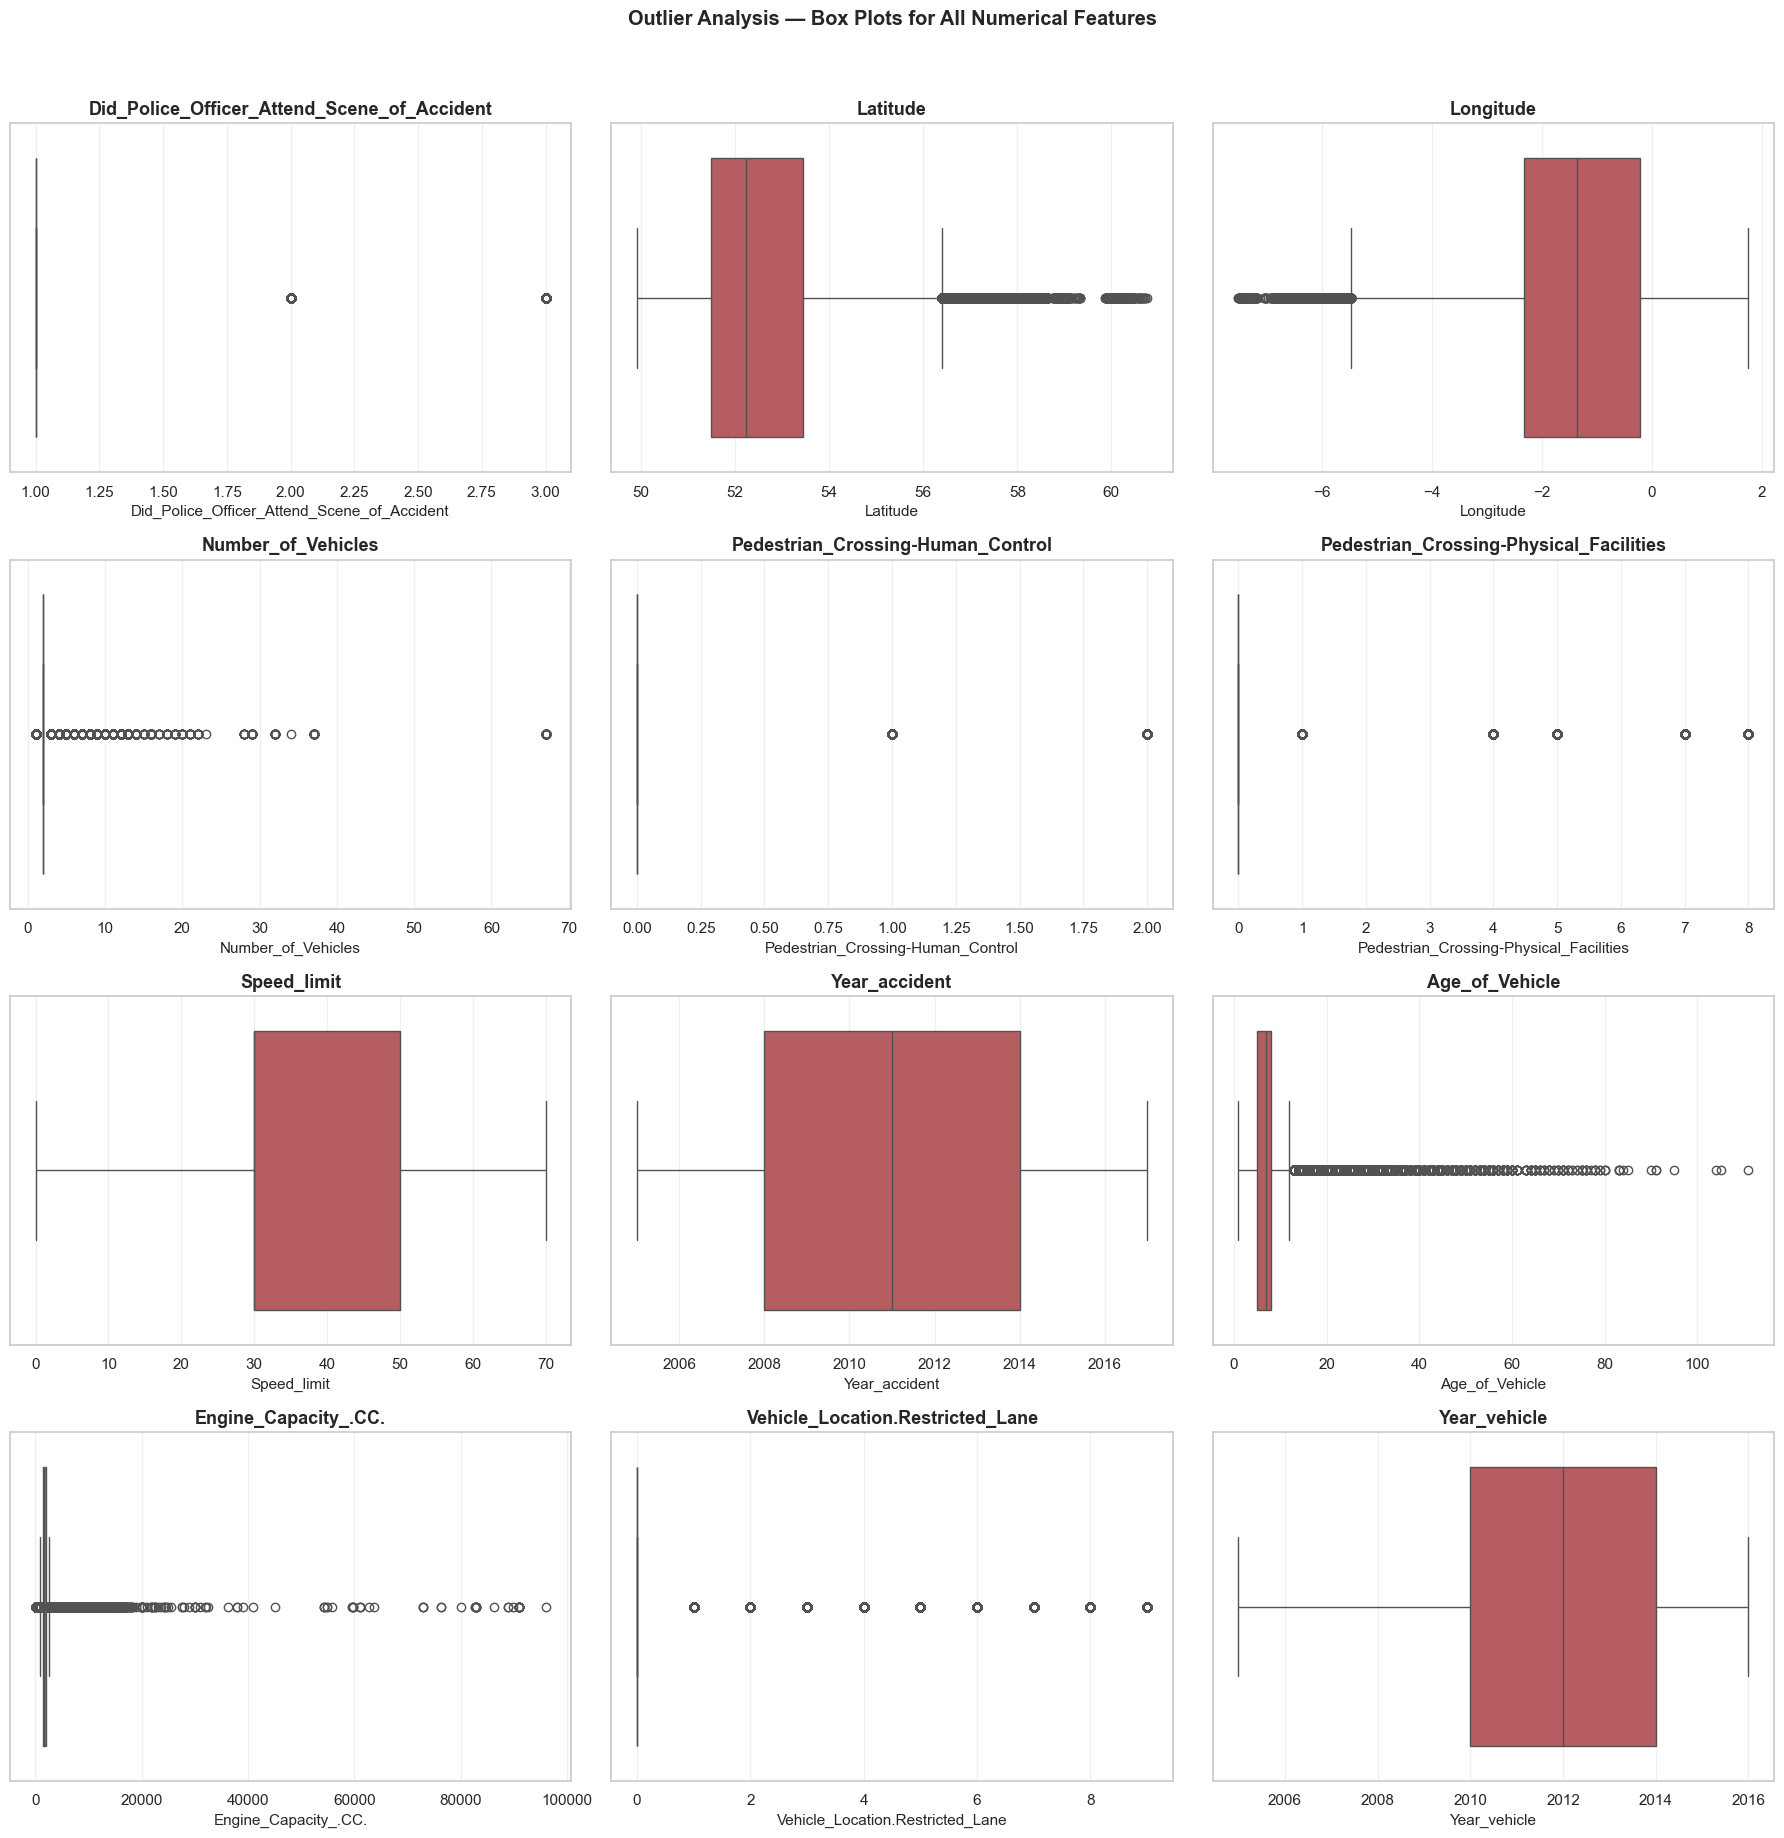

In [35]:
n_cols = len(numerical_columns)

if n_cols > 0:
    n_grid_cols = min(3, n_cols)
    n_grid_rows = int(np.ceil(n_cols / n_grid_cols))

    fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(6 * n_grid_cols, 4.5 * n_grid_rows))
    axes = np.array(axes).reshape(-1)

    for idx, col in enumerate(numerical_columns):
        sns.boxplot(x=df[col].dropna(), ax=axes[idx], color="#C44E52")
        axes[idx].set_title(f"{col}", fontweight="bold")
        axes[idx].set_xlabel(col)
        axes[idx].grid(axis="x", alpha=0.3)

    for idx in range(n_cols, len(axes)):
        axes[idx].axis("off")

    fig.suptitle("Outlier Analysis — Box Plots for All Numerical Features", fontweight="bold", y=1.02)
    plt.tight_layout()
    save_figure(fig, "outlier_analysis_combined_boxplots.png")
    plt.show()
else:
    print("[SKIPPED] No numerical columns available for outlier visualization.")


**Interpretation**

- **What it shows:** A single consolidated view of every numerical feature's outlier
  profile side-by-side, ranked by the percentage of values flagged as outliers under
  the 1.5×IQR rule.
- **Why it matters:** Features with a high outlier percentage are not automatically
  "wrong" — for count-based or coded fields, values outside the IQR whiskers often
  reflect genuinely rare-but-valid events (e.g., an accident involving an unusually
  high number of vehicles) rather than data entry errors.
- **Impact on prediction:** These outliers are deliberately **retained** at this stage,
  since severe accidents (the minority class of greatest interest) may disproportionately
  coincide with statistically "outlying" numerical values — removing them now could
  inadvertently discard some of the most informative rare-event records before
  modeling has even begun.


---
## 9. Research Insights

**Purpose:** Consolidate the analysis above into research-quality insights that will
directly inform Phase 5 (Feature Engineering) and later model development. Each insight
below should be read alongside the corresponding chart(s) generated earlier in this
notebook, which provide the specific values (counts, percentages, correlations) that
ground each observation for your actual dataset run.

---

### Insight 1 — Severe Class Imbalance in the Target Variable
- **Observation:** `Slight` severity accidents make up the large majority of records,
  with `Serious` and especially `Fatal` accidents forming small minority classes (see
  Section 2).
- **Reasoning:** This mirrors real-world road safety outcomes, where fatal collisions
  are rare relative to total accidents, but it is not evenly distributed for modeling
  purposes.
- **Possible Impact on Prediction:** Requires class-imbalance-aware modeling strategies
  (class weighting, resampling, or threshold tuning) and evaluation via macro F1/recall
  rather than raw accuracy.

### Insight 2 — Rural Roads Carry Disproportionate Severity Risk
- **Observation:** The severity composition chart for `Urban_or_Rural_Area` (Section
  6.7) is expected to show a higher proportion of `Serious`/`Fatal` outcomes in rural
  areas despite urban areas having more total accidents.
- **Reasoning:** Higher rural speed limits, longer emergency response times, and less
  forgiving roadside environments (trees, ditches, lack of barriers) plausibly explain
  this pattern.
- **Possible Impact on Prediction:** `Urban_or_Rural_Area` is likely to be one of the
  most important categorical predictors and should be prioritized in feature selection.

### Insight 3 — Speed Limit is Positively Associated with Severity
- **Observation:** The severity-by-speed-limit chart (Section 6.4) is expected to show
  an increasing share of severe outcomes at higher posted speed limits.
- **Reasoning:** Collision energy scales with the square of speed, so higher-speed
  roads mechanistically produce more severe injuries for a similar type of collision.
- **Possible Impact on Prediction:** `Speed_limit` (and its interaction with
  `Road_Type`) should be treated as a high-priority engineered feature, potentially
  including non-linear or binned representations.

### Insight 4 — Numerical Features are Right-Skewed and Discrete in Nature
- **Observation:** Count-based numerical features (e.g., `Number_of_Vehicles`) show
  right-skewed distributions with a long tail of rare, higher-value accidents (Section
  3).
- **Reasoning:** Most accidents involve a small, typical number of vehicles, while
  multi-vehicle pile-ups are rare but real events.
- **Possible Impact on Prediction:** Future feature engineering may benefit from
  log-transformation or capping/binning strategies for heavily skewed numerical
  features, once modeling begins.

### Insight 5 — Weather is a Weaker Standalone Predictor Than Expected
- **Observation:** The raw frequency of weather conditions (Section 4.1) is dominated
  by fine-weather accidents simply due to traffic exposure, and the severity-composition
  view (Section 6.1) may show only a modest shift in severe-outcome share across weather
  categories.
- **Reasoning:** Weather affects risk more through its interaction with speed choice,
  road surface, and visibility than as an independent driver of severity.
- **Possible Impact on Prediction:** Weather may be more useful as part of an
  interaction feature (e.g., combined with road surface) than as a standalone predictor.

### Insight 6 — Darkness Compounds Risk, Especially Without Street Lighting
- **Observation:** The light-conditions severity chart (Section 6.5) is expected to
  show a higher severe-outcome share under unlit darkness compared to daylight or
  lit darkness.
- **Reasoning:** Reduced visibility increases reaction time requirements and reduces a
  driver's ability to perceive hazards (pedestrians, cyclists, stationary vehicles).
- **Possible Impact on Prediction:** An interaction feature between `Light_Conditions`
  and `Urban_or_Rural_Area` (unlit rural darkness vs. lit urban darkness) may be more
  predictive than either feature alone.

### Insight 7 — Temporal Patterns Reflect Both Traffic Volume and Risk Exposure
- **Observation:** Accident counts by hour of day (Section 5.4) likely peak during
  morning and evening rush hours, driven primarily by traffic volume rather than
  elevated per-trip risk.
- **Reasoning:** More vehicles on the road mechanically produces more opportunities for
  collisions, independent of any change in individual driving risk.
- **Possible Impact on Prediction:** Raw accident counts by hour should not be
  conflated with severity risk by hour — a follow-up "severity by hour" cross-tab
  (extendable from this notebook's patterns) would better separate volume from risk.

### Insight 8 — Junction Configuration Shapes Collision Type and Severity
- **Observation:** Junction-related severity patterns (Section 6.6) and junction detail
  frequency (Section 4.5) together suggest that different junction types produce
  structurally different collision dynamics.
- **Reasoning:** Junctions introduce crossing and turning conflicts absent from open
  road driving, which can produce different impact angles and severities than
  single-vehicle or rear-end collisions.
- **Possible Impact on Prediction:** Junction detail and junction control should be
  retained as categorical predictors and considered for interaction terms with road
  type in feature engineering.

### Insight 9 — Vehicle Type Reflects Occupant Vulnerability
- **Observation:** The vehicle type frequency chart (Section 4.8) captures the mix of
  vehicles involved, ranging from well-protected cars to comparatively vulnerable
  motorcycles.
- **Reasoning:** Occupant protection varies dramatically by vehicle type; a collision
  of similar force can produce very different injury outcomes depending on whether the
  vehicle is a car, van, or motorcycle.
- **Possible Impact on Prediction:** `Vehicle_Type` is expected to be one of the more
  discriminative categorical features for severity prediction, particularly for
  distinguishing `Fatal`/`Serious` outcomes among motorcyclists.

### Insight 10 — Numerical Feature Correlations Warrant Feature Selection Review
- **Observation:** The correlation heatmap (Section 7) and its automatically filtered
  high-correlation pair table may surface some numerical features (e.g., geospatial
  coordinates) that are strongly related to one another.
- **Reasoning:** Redundant numerical features add dimensionality without necessarily
  adding new information, and can complicate interpretation for linear model families.
- **Possible Impact on Prediction:** Any highly correlated pairs identified should be
  reviewed during feature engineering to decide whether to retain both, combine them,
  or drop one — a decision deliberately deferred beyond this notebook's EDA-only scope.

### Insight 11 — Outliers May Encode Rare but Important Severe Events
- **Observation:** The consolidated outlier analysis (Section 8) shows that a
  non-trivial share of numerical values fall outside standard IQR bounds for several
  features.
- **Reasoning:** In accident data, statistically "outlying" values (e.g., unusually
  high vehicle counts) can coincide with genuinely rare, high-severity events rather
  than data errors.
- **Possible Impact on Prediction:** Outliers should **not** be blindly removed in
  Phase 5; any outlier handling strategy should be evaluated for its effect on minority
  (`Fatal`/`Serious`) class representation before being applied.

---

> These insights are intended as a structured starting point — once this notebook is
> executed against the full cleaned dataset, each insight's "Observation" should be
> cross-checked and refined against the actual printed statistics, percentages, and
> correlation values produced above.
